# API Sentinel — Secure REST API Monitoring and Attack Detection System

## Notebook overview

This notebook is organized top-to-bottom in the order it should be executed. Each cell either *defines* something (helper, model, schema) or *runs* something (training, serving, test).


> **Tip:** Run sections 1–22 once per kernel session; sections 23–29 can be re-run as needed during live testing.


## 1. Consolidated Imports

All third-party and standard library imports are centralized below so individual cells stay focused on logic. **Run this cell first.**


In [70]:
# =========================================================
# Section 1. Consolidated Imports
# =========================================================
# All imports used across the notebook are centralized here so that
# later cells can focus on logic. Run this cell first.

# --- stdlib ---
import os
import re
import csv
import json
import time
import uuid
import sqlite3
import hashlib
import smtplib
import asyncio
import threading
from datetime import datetime
from collections import defaultdict, deque
from typing import Dict, Any, Optional
from urllib.parse import urlparse, parse_qs, unquote
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# --- third-party ---
import numpy as np
import pandas as pd
import joblib
import httpx
import requests
import nest_asyncio
import uvicorn

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse, Response

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

# --- optional: TensorFlow (only needed for the MITM autoencoder) ---
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except ImportError:
    tf = None
    print('Note: TensorFlow not installed; MITM autoencoder cells will be skipped.')

print('All imports loaded.')


All imports loaded.


## 1b. Helper — Metrics Saver

Centralized helper that computes accuracy, precision, recall, F1, ROC-AUC, PR-AUC and a confusion matrix for any model, then saves them to a JSON file **and** to the `model_runs` SQLite table. Every training cell calls this so results are stored in a consistent format.

In [71]:
# =========================================================
# Section 1b. Metrics Helper
# =========================================================
import json
import sqlite3
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report,
)


def evaluate_and_save(
    model_name,
    y_true,
    y_prob,
    y_pred,
    threshold=None,
    extra=None,
    db_path="sam_ads.db",
):
    """Compute metrics, save to JSON, also write to model_runs table."""
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    metrics = {
        "model_name": model_name,
        "trained_at": datetime.utcnow().isoformat(),
        "threshold": float(threshold) if threshold is not None else None,
        "n_samples": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if y_prob is not None else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if y_prob is not None else None,
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) else 0.0,
        "confusion_matrix": {"tn": int(tn), "fp": int(fp),
                             "fn": int(fn), "tp": int(tp)},
        "classification_report": classification_report(
            y_true, y_pred, output_dict=True, zero_division=0
        ),
    }
    if extra:
        metrics.update(extra)

    # Save JSON
    fname = f"{model_name}_metrics.json"
    with open(fname, "w") as f:
        json.dump(metrics, f, indent=2, default=str)

    auc_str = f"{metrics['roc_auc']:.4f}" if metrics["roc_auc"] is not None else "n/a"
    print(f"💾 {fname}  |  acc={metrics['accuracy']:.4f}  "
          f"f1={metrics['f1']:.4f}  auc={auc_str}")

    # Insert into model_runs table
    try:
        c = sqlite3.connect(db_path)
        c.execute("""
            INSERT INTO model_runs
            (model_name, trained_at, accuracy, precision_score,
             recall, f1, roc_auc, threshold, metrics_json)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            model_name, metrics["trained_at"],
            metrics["accuracy"], metrics["precision"],
            metrics["recall"], metrics["f1"],
            metrics["roc_auc"], metrics["threshold"],
            json.dumps(metrics, default=str),
        ))
        c.commit()
        c.close()
    except Exception as e:
        print(f"   (DB write skipped: {e})")

    return metrics


print("✅ evaluate_and_save() ready")


✅ evaluate_and_save() ready


## 2. Database Schema Setup (SQLite)

Creates every table the system uses for logs, predictions, alerts, blocked requests, clients, feedback labels, training runs, and email configuration.


In [72]:
# (imports consolidated into section 1)
conn = sqlite3.connect("sam_ads.db")
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

# =====================================================
# api_logs (FINAL VERSION)
# =====================================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS api_logs (
    id TEXT PRIMARY KEY,
    timestamp TEXT NOT NULL,
    ip_address TEXT,
    method TEXT,
    path TEXT,
    backend_url TEXT,
    headers TEXT,
    payload TEXT,
    query_params TEXT,
    user_agent TEXT,
    authorization TEXT,
    token_hash TEXT,
    cookie TEXT,
    content_length INTEGER,
    response_time_ms REAL,
    response_status INTEGER,
    decision TEXT,
    reason TEXT,
    predicted_class TEXT,
    supervised_score REAL,
    anomaly_flag INTEGER,
    iso_score REAL,
    label TEXT,
    extracted_features TEXT,
    mitm_class TEXT,
    mitm_score REAL,
    rule_decision TEXT,
    rule_label TEXT,
    rule_risk_score REAL,
    rule_reasons TEXT,
    fusion_confidence REAL,
    fusion_risk_score REAL,

    -- MODEL INFO
    rf_model_version TEXT,
    iso_model_version TEXT,
    session_behavior_version TEXT,
    rf_threshold REAL,
    iso_threshold REAL,
    feature_file TEXT,

    -- SESSION DATA
    session_id TEXT,
    request_fingerprint TEXT,
    replay_flag INTEGER,
    replay_count INTEGER,
    ip_changed INTEGER,
    user_agent_changed INTEGER,
    sequence_anomaly INTEGER,
    hijack_score REAL,
    mitm_reasons TEXT
)
""")

# =====================================================
# predictions
# =====================================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS predictions (
    prediction_id INTEGER PRIMARY KEY AUTOINCREMENT,
    log_id TEXT NOT NULL,
    timestamp TEXT NOT NULL,
    supervised_score REAL,
    anomaly_flag INTEGER,
    mitm_class TEXT,
    mitm_score REAL,
    rule_decision TEXT,
    rule_label TEXT,
    rule_risk_score REAL,
    fusion_confidence REAL,
    fusion_risk_score REAL,
    predicted_class TEXT,
    decision TEXT,
    reason TEXT,
    rf_model_version TEXT,
    iso_model_version TEXT,
    rf_threshold REAL,
    iso_threshold REAL,
    feature_file TEXT,
    FOREIGN KEY (log_id) REFERENCES api_logs(id) ON DELETE CASCADE
)
""")

# =====================================================
# alerts
# =====================================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS alerts (
    alert_id INTEGER PRIMARY KEY AUTOINCREMENT,
    log_id TEXT NOT NULL,
    timestamp TEXT NOT NULL,
    ip_address TEXT,
    path TEXT,
    attack_type TEXT,
    severity TEXT,
    decision TEXT,
    message TEXT,
    is_resolved INTEGER DEFAULT 0,
    FOREIGN KEY (log_id) REFERENCES api_logs(id) ON DELETE CASCADE
)
""")

# =====================================================
# clients
# =====================================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS clients (
    client_id INTEGER PRIMARY KEY AUTOINCREMENT,
    ip_address TEXT UNIQUE,
    token_hash TEXT,
    first_seen TEXT,
    last_seen TEXT,
    request_count INTEGER DEFAULT 0,
    blocked_count INTEGER DEFAULT 0,
    flagged_count INTEGER DEFAULT 0
)
""")

# =====================================================
# EMAIL TABLES
# =====================================================
cursor.execute("""
CREATE TABLE IF NOT EXISTS email_alert_config (
    config_id       INTEGER PRIMARY KEY AUTOINCREMENT,
    recipient_email TEXT NOT NULL UNIQUE,
    is_active       INTEGER NOT NULL DEFAULT 1,
    created_at      TEXT NOT NULL DEFAULT (datetime('now')),
    updated_at      TEXT NOT NULL DEFAULT (datetime('now'))
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS email_alert_history (
    alert_email_id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT NOT NULL,
    recipient TEXT,
    severity TEXT,
    trigger TEXT,
    ip_address TEXT,
    endpoint TEXT,
    delivery_status TEXT,
    error_message TEXT,
    email_html TEXT,
    threat_score REAL
)
""")

cursor.execute("""
INSERT OR IGNORE INTO email_alert_config (config_id, recipient_email, updated_at)
VALUES (1, '', datetime('now'))
""")

# =====================================================
# model_runs (NEW: stores per-training-run metrics)
# =====================================================
cursor.execute("""
CREATE TABLE IF NOT EXISTS model_runs (
    run_id INTEGER PRIMARY KEY AUTOINCREMENT,
    model_name TEXT,
    trained_at TEXT,
    accuracy REAL,
    precision_score REAL,
    recall REAL,
    f1 REAL,
    roc_auc REAL,
    threshold REAL,
    metrics_json TEXT
)
""")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS feedback_labels (
        feedback_id TEXT PRIMARY KEY,
        log_id TEXT NOT NULL,
        original_label TEXT,
        admin_label TEXT NOT NULL,
        feedback_notes TEXT,
        created_at TEXT NOT NULL,
        used_in_training INTEGER DEFAULT 0
    )
    """)

cursor.execute("""
    CREATE TABLE IF NOT EXISTS model_training_runs (
        training_run_id TEXT PRIMARY KEY,
        started_at TEXT NOT NULL,
        finished_at TEXT,
        training_rows INTEGER,
        validation_rows INTEGER,
        rf_model_file TEXT,
        iso_model_file TEXT,
        accuracy REAL,
        status TEXT,
        notes TEXT
    )
    """)
# =====================================================
# FINALIZE
# =====================================================

conn.commit()
conn.close()

print("✅ Database created with FULL schema (no ALTER needed)")

✅ Database created with FULL schema (no ALTER needed)


## 3. Email Alert Recipient Configuration

Sets (or updates) the recipient address used when the enforcement engine decides to send an alert. Edit the address in the cell before running.


In [73]:
# (imports consolidated into section 1)
conn = sqlite3.connect("sam_ads.db")
cursor = conn.cursor()

cursor.execute("""
INSERT INTO email_alert_config (config_id, recipient_email, updated_at)
VALUES (1, ?, datetime('now'))
ON CONFLICT(config_id)
DO UPDATE SET
    recipient_email = excluded.recipient_email,
    updated_at = excluded.updated_at
""", ("rafqa.elhaddad@lau.edu",))

conn.commit()
conn.close()

print("✅ Email recipient saved")

✅ Email recipient saved


## 4. Helper — Model Registry

Defines metadata for every trained model (Random Forest, Isolation Forest, MITM Autoencoder) and writes it to `model_registry.json`. The proxy reads this file at startup.


In [74]:
# (imports consolidated into section 1)
model_registry = {
    "random_forest": {
        "model_name": "RandomForestClassifier",
        "version": "rf_v1",
        "model_file": "rf_model.pkl",
        "feature_file": "feature_columns.pkl",
        "threshold": 0.4,
        "training_date": "2026-04-14",
        "notes": "Main supervised intrusion detection model"
    },
    "isolation_forest": {
        "model_name": "IsolationForest",
        "version": "iso_v1",
        "model_file": "iso_model.pkl",
        "feature_file": "feature_columns.pkl",
        "threshold": None,
        "training_date": "2026-04-14",
        "notes": "Unsupervised anomaly detection model"
    },
    "mitm_autoencoder": {
        "model_name": "MITM Autoencoder",
        "version": "mitm_v1",
        "model_file": "mitm_autoencoder.keras",
        "scaler_file": "mitm_scaler.pkl",
        "config_file": "mitm_config.json",
        "threshold": None,   # will be filled from mitm_config
        "training_date": "2026-04-14",
        "notes": "MITM anomaly behavior detection"
    }
}

with open("model_registry.json", "w") as f:
    json.dump(model_registry, f, indent=2)

print("model_registry.json created")

model_registry.json created


## 5. Helper — Rule-Based Detection Engine

Regex/heuristic based detector for classic attack patterns (SQLi, XSS, path traversal, command injection, etc.). Produces a `rule_result` that feeds into the hybrid decision engine.


In [75]:
# ===============================
# SECTION 5: RULE ENGINE (OPTIMIZED — uses shared patterns from Section 9)
# ===============================
# Changes:
#   * Patterns are now imported from the feature-builder cell (single source
#     of truth). No more drift between training-time and runtime regex.
#   * Removed "flag-level" SQL patterns that just matched a single keyword.
#     Either a request matches a real injection pattern or it doesn't.
#   * Tampering check no longer flags Content-Length mismatch alone — that
#     fires constantly when frameworks rewrite bodies. We require it to
#     coincide with another signal (auth missing on protected endpoint).
#
# Used for: explainability + tie-breaking on borderline model scores.
# NOT used as: a primary detection signal.

from urllib.parse import unquote_plus
from collections import defaultdict, deque
import time, hashlib, re
from typing import Dict, Any

class RuleBasedDetectionEngine:
    def __init__(
        self,
        rate_window_seconds: int = 60,
        rate_limit_per_ip: int = 60,
        repeated_token_window_seconds: int = 120,
        repeated_token_threshold: int = 15,
        token_multi_ip_window_seconds: int = 300,
    ):
        self.rate_window_seconds = rate_window_seconds
        self.rate_limit_per_ip = rate_limit_per_ip
        self.repeated_token_window_seconds = repeated_token_window_seconds
        self.repeated_token_threshold = repeated_token_threshold
        self.token_multi_ip_window_seconds = token_multi_ip_window_seconds

        self.ip_request_times = defaultdict(deque)
        self.token_usage = defaultdict(deque)

        # Patterns come from the shared module defined in Section 9.
        # If running this cell standalone (no shared module), define minimal
        # safe defaults. In the notebook, SQL_PATTERNS etc. are global.
        self.sql_patterns = list(globals().get("SQL_PATTERNS", []))
        self.xss_patterns = list(globals().get("XSS_PATTERNS", []))
        self.cmd_patterns = list(globals().get("CMD_PATTERNS", []))
        self.traversal_patterns = list(globals().get("TRAVERSAL_PATTERNS", []))

    def evaluate_request(self, req: Dict[str, Any]) -> Dict[str, Any]:
        client_ip = req.get("client_ip", "unknown")
        headers = req.get("headers", {}) or {}
        body = str(req.get("body", "") or "")
        path = str(req.get("path", "") or "")
        method = str(req.get("method", "") or "")
        qp = req.get("query_params", {}) or {}

        text = self._build_text(method, path, qp, body)

        reasons = []
        score = 0
        decision = "allow"
        label = "normal"

        # 1. Pattern-based attack checks (each match scores 90, blocks)
        for cat, patterns, lbl in [
            ("SQLi", self.sql_patterns, "malicious"),
            ("XSS", self.xss_patterns, "malicious"),
            ("Path traversal", self.traversal_patterns, "malicious"),
            ("Command injection", self.cmd_patterns, "malicious"),
        ]:
            for p in patterns:
                if re.search(p, text, re.IGNORECASE | re.DOTALL):
                    reasons.append(f"{cat} pattern matched")
                    score += 90
                    decision, label = "block", "malicious"
                    break   # one match per category is enough
            if decision == "block":
                break

        # 2. Rate limit
        rr = self._check_rate(client_ip)
        if rr["matched"]:
            reasons.extend(rr["reasons"])
            score += rr["score"]
            if rr["decision"] == "block":
                decision, label = "block", "malicious"
            elif decision == "allow":
                decision, label = "flag", "suspicious"

        # 3. Protected endpoint without auth
        if any(path.lower().startswith(p) for p in ("/admin", "/transfer", "/internal")) \
                and not (headers.get("authorization") or headers.get("Authorization")):
            reasons.append("protected endpoint without authorization")
            score += 35
            if decision == "allow":
                decision, label = "flag", "suspicious"

        return {
            "decision": decision,
            "label": label,
            "risk_score": int(min(score, 100)),
            "reasons": reasons,
        }

    def _build_text(self, method, path, qp, body):
        qp_text = " ".join(f"{k}={v}" for k, v in qp.items())
        raw = f"{method} {path} {qp_text} {body}"
        # Deep URL decode so encoded payloads are caught
        prev = None
        cur = raw
        for _ in range(4):
            if cur == prev:
                break
            prev = cur
            try:
                cur = unquote_plus(cur)
            except Exception:
                break
        return cur.lower()

    def _check_rate(self, ip):
        now = time.time()
        q = self.ip_request_times[ip]
        q.append(now)
        while q and now - q[0] > self.rate_window_seconds:
            q.popleft()
        n = len(q)
        if n > self.rate_limit_per_ip * 3:
            return {"matched": True, "decision": "block", "score": 80,
                    "reasons": [f"IP flooding: {n}/{self.rate_window_seconds}s"]}
        if n > self.rate_limit_per_ip:
            return {"matched": True, "decision": "flag", "score": 35,
                    "reasons": [f"high request rate: {n}/{self.rate_window_seconds}s"]}
        return {"matched": False, "decision": "allow", "score": 0, "reasons": []}


## 6. Helper — Hybrid Decision Engine

Fuses the outputs of the supervised model, anomaly detector, rule engine, and MITM detector into a single decision with a risk score and confidence.


In [76]:
# ===============================
# SECTION 6: HybridDecisionEngine — REMOVED
# ===============================
# The fusion logic previously implemented as a separate class is now
# inlined in predict_request (Section 24.6). Having two parallel fusion
# implementations was the main source of bugs and behavior drift between
# the offline evaluation and the live proxy.
#
# This cell is intentionally a no-op so cell numbering stays stable.


## 8. Helper — Session / Behavior Feature Builder

Tracks per-session history (IPs, user agents, paths, fingerprints) and emits behavioral features used by the proxy at request time.


In [77]:
# ===============================
# SESSION / BEHAVIOR FEATURES FOR LIVE PROXY
# ===============================

from collections import defaultdict, deque
from datetime import datetime
import numpy as np

SESSION_STORE = defaultdict(lambda: {
    "timestamps": deque(maxlen=50),
    "ips": deque(maxlen=20),
    "user_agents": deque(maxlen=20),
    "paths": deque(maxlen=30),
    "fingerprints": deque(maxlen=50),
    "replay_count": 0
})

def build_behavior_features(session_id, ip_address, user_agent, path, fingerprint, now_ts):
    state = SESSION_STORE[session_id]

    # replay
    replay_flag = int(fingerprint in state["fingerprints"])
    if replay_flag:
        state["replay_count"] += 1

    state["timestamps"].append(now_ts)
    state["ips"].append(ip_address)
    state["user_agents"].append(user_agent)
    state["paths"].append(path)
    state["fingerprints"].append(fingerprint)

    times = list(state["timestamps"])
    req_rate_60s = 0
    if times:
        req_rate_60s = sum((now_ts - t) <= 60 for t in times)

    features = {
        "session_request_count": len(state["timestamps"]),
        "distinct_ip_count": len(set(state["ips"])),
        "distinct_user_agent_count": len(set(state["user_agents"])),
        "distinct_path_count": len(set(state["paths"])),
        "replay_count": state["replay_count"],
        "request_rate_60s": req_rate_60s,
        "replay_flag": replay_flag,
        "possible_hijack_flag": int(len(set(state["ips"])) > 1 and len(set(state["user_agents"])) > 1),
    }

    return features



## 9. ML Training — Dataset Preprocessing & Feature Engineering

Loads the training dataset, cleans it, extracts features (header/payload/query stats, regex hit counts, etc.) and writes `feature_columns.pkl`.


In [78]:
# ===============================
# SECTION 9: DATA PREP + SHARED FEATURE BUILDER (OPTIMIZED)
# ===============================
# Key changes vs previous version:
#   1. CMD_PATTERNS no longer contains bare ";", "|", "&&", "||" — those
#      occur in every benign URL and were the main source of false positives.
#   2. Removed binary "has_*" rule-flag features. The model now learns from
#      *statistical* features (counts, lengths, ratios, entropy). This is the
#      single biggest change to make detection model-driven, not rule-driven.
#   3. Added entropy and character-class-ratio features that are highly
#      discriminative for injection attacks but DON'T leak rule decisions.
#   4. Single source of truth: SQL_PATTERNS / XSS_PATTERNS / TRAVERSAL_PATTERNS
#      live in this cell; the rule engine and live extractor both import them.

import re
import json
import math
import numpy as np
import pandas as pd
import joblib
from urllib.parse import urlparse, parse_qs, unquote_plus
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
df = pd.read_csv("csic_database.csv")

rename_map = {
    "URL": "url", "content": "payload", "Method": "method",
    "User-Agent": "user_agent", "lenght": "length",
    "classification": "classification",
}
df = df.rename(columns=rename_map)

for col in ["url", "payload", "method", "user_agent"]:
    if col not in df.columns:
        df[col] = ""

# -------------------------------
# 2. ROBUST LABEL MAPPING
# -------------------------------
def build_binary_label(frame):
    for col in ["classification", "label", "Class", "attack_type"]:
        if col not in frame.columns:
            continue
        raw = frame[col].astype(str).str.strip().str.lower()
        if set(raw.dropna().unique()).issubset({"0", "1"}):
            return raw.astype(int)
        normal = {"normal", "benign", "legitimate", "good", "valid", "0"}
        attack = {"anomalous", "anomaly", "attack", "malicious", "bad", "1"}
        y = raw.apply(lambda x: 0 if x in normal else (1 if x in attack else (
            0 if "normal" in x or "benign" in x else 1)))
        if y.nunique() > 1:
            return y.astype(int)
    raise ValueError("Could not build binary label.")

df["label"] = build_binary_label(df)
print("Label counts:\n", df["label"].value_counts())

# -------------------------------
# 3. SHARED HELPERS (single source of truth)
# -------------------------------
def deep_decode(x, max_passes=4):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    x = str(x)
    for _ in range(max_passes):
        d = unquote_plus(x)
        if d == x:
            break
        x = d
    return x

def clean_text(x):
    return deep_decode(x).lower().strip()

def shannon_entropy(s):
    if not s:
        return 0.0
    counts = {}
    for ch in s:
        counts[ch] = counts.get(ch, 0) + 1
    n = len(s)
    return -sum((c/n) * math.log2(c/n) for c in counts.values())

# -------------------------------
# 4. PATTERNS (used by feature builder AND rule engine)
# -------------------------------
SQL_PATTERNS = [
    r"\bunion\b\s+(all\s+)?\bselect\b",
    r"\bor\b\s+\d+\s*=\s*\d+",
    r"\band\b\s+\d+\s*=\s*\d+",
    r"'\s*or\s*'?\d+'?\s*=\s*'?\d+",
    r"\bdrop\b\s+\btable\b",
    r"\binsert\b\s+\binto\b",
    r"\bdelete\b\s+\bfrom\b",
    r"\bupdate\b[^,;]{0,80}\bset\b",
    r"\binformation_schema\b",
    r"\bsleep\s*\(\s*\d+\s*\)",
    r"\bbenchmark\s*\(",
    r"\bxp_cmdshell\b",
    r";\s*--",
    r"--\s*$",
    r"/\*.*?\*/",
]

XSS_PATTERNS = [
    r"<script[^>]*>",
    r"</script>",
    r"javascript\s*:",
    r"\bon(error|load|click|mouseover|focus|submit)\s*=",
    r"<img[^>]+on\w+\s*=",
    r"<svg[^>]+on\w+\s*=",
    r"<iframe[^>]*>",
    r"document\s*\.\s*cookie",
    r"\beval\s*\(",
    r"\bfromcharcode\s*\(",
]

# IMPORTANT: command injection requires a recognizable command shape.
# We do NOT include bare ";", "|", "&&", "||" here — those are in every URL.
CMD_PATTERNS = [
    r";\s*(rm|cat|ls|wget|curl|nc|bash|sh|powershell)\b",
    r"\|\s*(rm|cat|ls|wget|curl|nc|bash|sh|powershell)\b",
    r"&&\s*(rm|cat|ls|wget|curl|nc|bash|sh|powershell)\b",
    r"\$\(.+?\)",
    r"`[^`]+`",
    r"\brm\s+-rf\s+/",
]

TRAVERSAL_PATTERNS = [
    r"\.\./",
    r"\.\.\\",
    r"%2e%2e%2f",
    r"/etc/passwd",
    r"/etc/shadow",
    r"\bwindows\\system32\b",
    r"\bboot\.ini\b",
]

BAD_UA_PATTERNS = [r"sqlmap", r"nikto", r"nmap", r"acunetix", r"\bburp\b",
                   r"owasp\s*zap", r"\bzap\b", r"masscan", r"gobuster"]

def count_pattern_hits(text, patterns):
    return sum(1 for p in patterns if re.search(p, text, re.IGNORECASE | re.DOTALL))

# -------------------------------
# 5. FEATURE BUILDER (model-friendly: counts/ratios, no hard rule flags)
# -------------------------------
def build_request_features(path, payload="", query_params=None,
                           headers=None, method="GET", user_agent=""):
    headers = headers or {}
    lower_headers = {str(k).lower(): str(v) for k, v in headers.items()}

    method_text = clean_text(method)
    user_agent_text = clean_text(user_agent or lower_headers.get("user-agent", ""))
    payload_text = clean_text(payload)
    path_text = clean_text(path)

    # Parse query string from path AND from explicit query_params
    parsed = urlparse(path_text)
    raw_path = parsed.path if parsed.path else path_text
    merged_query = {k: v for k, v in parse_qs(parsed.query, keep_blank_values=True).items()}

    if isinstance(query_params, dict):
        for k, v in query_params.items():
            merged_query[clean_text(str(k))] = (
                [clean_text(str(i)) for i in v] if isinstance(v, (list, tuple))
                else clean_text(str(v))
            )

    query_string = "&".join(
        f"{k}={','.join(v) if isinstance(v, list) else v}"
        for k, v in merged_query.items()
    )

    # Combined text — NO header values; tokens often look like keywords.
    full_text = f"{method_text} {raw_path} {query_string} {payload_text}".lower().strip()

    # Pattern hit counts (kept as integers — model decides their weight)
    sql_count = count_pattern_hits(full_text, SQL_PATTERNS)
    xss_count = count_pattern_hits(full_text, XSS_PATTERNS)
    cmd_count = count_pattern_hits(full_text, CMD_PATTERNS)
    trav_count = count_pattern_hits(full_text, TRAVERSAL_PATTERNS)
    bad_ua_count = count_pattern_hits(user_agent_text, BAD_UA_PATTERNS)

    n = max(len(full_text), 1)

    return {
        # Length features
        "url_length": len(raw_path),
        "query_length": len(query_string),
        "payload_length": len(payload_text),
        "full_request_length": len(full_text),
        "user_agent_length": len(user_agent_text),

        # Structural features
        "path_depth": raw_path.strip("/").count("/") + (1 if raw_path.strip("/") else 0),
        "param_count": len(merged_query),
        "header_count": len(headers),

        # Character counts
        "equals_count": full_text.count("="),
        "ampersand_count": full_text.count("&"),
        "slash_count": full_text.count("/"),
        "dot_count": full_text.count("."),
        "percent_count": full_text.count("%"),
        "digit_count": sum(c.isdigit() for c in full_text),
        "uppercase_count": sum(c.isupper() for c in full_text),
        "special_char_count": len(re.findall(r"[<>'\";(){}\[\]$`|]", full_text)),

        # Ratios — these make features comparable across short/long requests
        "digit_ratio": sum(c.isdigit() for c in full_text) / n,
        "special_char_ratio": len(re.findall(r"[<>'\";(){}\[\]$`|]", full_text)) / n,
        "percent_ratio": full_text.count("%") / n,

        # Entropy — high entropy often indicates encoded/obfuscated payloads
        "payload_entropy": shannon_entropy(payload_text),
        "query_entropy": shannon_entropy(query_string),

        # Pattern hit COUNTS only (no binary "has_*" — let the model decide
        # what counts as "enough" to be malicious)
        "sql_pattern_hits": sql_count,
        "xss_pattern_hits": xss_count,
        "cmd_pattern_hits": cmd_count,
        "traversal_pattern_hits": trav_count,
        "bad_ua_pattern_hits": bad_ua_count,

        # Header & method features
        "has_cookie": int("cookie" in lower_headers),
        "has_authorization": int("authorization" in lower_headers),
        "method_GET": int(method_text == "get"),
        "method_POST": int(method_text == "post"),
        "method_PUT": int(method_text == "put"),
        "method_DELETE": int(method_text == "delete"),
        "method_PATCH": int(method_text == "patch"),
    }

# -------------------------------
# 6. APPLY TO DATASET
# -------------------------------
for col in ["url", "payload", "method", "user_agent"]:
    df[col] = df[col].apply(clean_text)

rows = [
    build_request_features(
        path=r["url"], payload=r["payload"],
        headers={"user-agent": r["user_agent"]},
        method=r["method"], user_agent=r["user_agent"]
    )
    for _, r in df.iterrows()
]

feat_df = pd.DataFrame(rows)
feature_columns = list(feat_df.columns)
X = feat_df.fillna(0)
y = df["label"].astype(int).reset_index(drop=True)

print("Final X shape:", X.shape)
print("Feature columns:", feature_columns)
print("Label distribution:\n", y.value_counts())

# -------------------------------
# 7. TRAIN / VAL / TEST SPLIT
# -------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

joblib.dump(feature_columns, "feature_columns.pkl")
print("Saved feature_columns.pkl")


Label counts:
 label
0    36000
1    25065
Name: count, dtype: int64
Final X shape: (61065, 33)
Feature columns: ['url_length', 'query_length', 'payload_length', 'full_request_length', 'user_agent_length', 'path_depth', 'param_count', 'header_count', 'equals_count', 'ampersand_count', 'slash_count', 'dot_count', 'percent_count', 'digit_count', 'uppercase_count', 'special_char_count', 'digit_ratio', 'special_char_ratio', 'percent_ratio', 'payload_entropy', 'query_entropy', 'sql_pattern_hits', 'xss_pattern_hits', 'cmd_pattern_hits', 'traversal_pattern_hits', 'bad_ua_pattern_hits', 'has_cookie', 'has_authorization', 'method_GET', 'method_POST', 'method_PUT', 'method_DELETE', 'method_PATCH']
Label distribution:
 label
0    36000
1    25065
Name: count, dtype: int64
Train: (39081, 33), Val: (9771, 33), Test: (12213, 33)
Saved feature_columns.pkl


## 10. ML Training — Supervised (Random Forest)

Trains the Random Forest classifier that outputs the supervised maliciousness score.


In [79]:
# ===============================
# SECTION 10: SUPERVISED MODEL — RandomForest + threshold tuned for FP control
# ===============================
# Changes:
#   * Removed the hard floor of 0.85 on the RF threshold — that floor caused
#     many true attacks with calibrated probability ~0.6–0.8 to be missed.
#   * Threshold is now picked on the validation set to maximize F1 while
#     keeping false-positive rate <= 5%. This directly addresses your
#     "normal payload returns suspicious" complaint.
#   * Reduced max_depth slightly to discourage memorizing rule-flag features
#     (which we removed anyway in the new feature set).

import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_curve, roc_auc_score,
)

if len(np.unique(y_train)) < 2:
    raise ValueError("Training labels still contain only one class.")

# 1. Fit base RF on TRAIN
rf_base = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,                    # shallower -> better generalization
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf_base.fit(X_train, y_train)

# 2. Calibrate probabilities on VAL (isotonic gives well-calibrated scores)
rf_model = CalibratedClassifierCV(rf_base, method="isotonic", cv="prefit")
rf_model.fit(X_val, y_val)

# 3. Pick threshold: max F1 subject to FPR <= 5%
y_val_prob = rf_model.predict_proba(X_val)[:, 1]
prec, rec, thresh = precision_recall_curve(y_val, y_val_prob)

# Compute FPR at each threshold
n_neg = (y_val == 0).sum()
fpr_at = []
for t in thresh:
    fp = ((y_val_prob >= t) & (y_val == 0)).sum()
    fpr_at.append(fp / max(n_neg, 1))
fpr_at = np.array(fpr_at)

f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
mask = fpr_at <= 0.05
if mask.any():
    candidate_idx = np.argmax(np.where(mask, f1_scores, -1))
else:
    candidate_idx = int(np.argmax(f1_scores))
best_threshold = float(thresh[candidate_idx])
best_threshold = max(best_threshold, 0.50)   # never go below 0.50

# 4. Evaluate on TEST
y_test_prob = rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(f"Chosen RF threshold: {best_threshold:.3f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

# 5. Feature importances
importance = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features:\n", importance.head(15))

# 6. Save
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(best_threshold, "rf_threshold.pkl")
print("Saved rf_model.pkl and rf_threshold.pkl")

# Save metrics to model_runs (use existing helper)
try:
    evaluate_and_save(
        "rf_model", y_true=y_test, y_prob=y_test_prob, y_pred=y_test_pred,
        threshold=best_threshold,
        extra={"top_features": importance.head(20).to_dict()}
    )
except NameError:
    pass


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Chosen RF threshold: 0.517
Test accuracy: 0.9050
Test ROC-AUC:  0.9768
              precision    recall  f1-score   support

           0     0.8800    0.9714    0.9234      7200
           1     0.9517    0.8097    0.8750      5013

    accuracy                         0.9050     12213
   macro avg     0.9158    0.8905    0.8992     12213
weighted avg     0.9094    0.9050    0.9035     12213

Confusion matrix:
 [[6994  206]
 [ 954 4059]]

Top 15 features:
 full_request_length    0.165045
digit_ratio            0.137186
digit_count            0.103228
dot_count              0.076317
slash_count            0.063903
url_length             0.060970
equals_count           0.053598
path_depth             0.044534
special_char_ratio     0.043794
special_char_count     0.042236
payload_entropy        0.041439
query_length           0.039443
query_entropy          0.036424
payload_length         0.036379
ampersand_count        0.021663
dtype: float64
Saved rf_model.pkl and rf_threshold.pkl
💾 

/tmp/ipykernel_2091/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


## 11. ML Training — Unsupervised (Isolation Forest)

Trains the Isolation Forest anomaly detector on the benign-only subset of the training data.


In [80]:
# ===============================
# STEP 10: UNSUPERVISED MODEL (Isolation Forest) — leak-free
# ===============================
# Uses X_train / X_val / X_test from section 9.
# - Fits on benign-only TRAIN rows
# - Picks threshold on VAL benign distribution
# - Evaluates ONCE on TEST
# - Saves metrics JSON + model_runs DB row

import numpy as np
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train_normal = X_train[y_train == 0]

iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
)
iso_model.fit(X_train_normal)

# Threshold from benign validation distribution (98th percentile)
val_anom = -iso_model.score_samples(X_val)
iso_threshold = float(np.percentile(val_anom[y_val == 0], 98))

# Evaluate on TEST
test_anom = -iso_model.score_samples(X_test)
y_test_pred = (test_anom >= iso_threshold).astype(int)

print("Isolation threshold:", iso_threshold)
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_anom))

joblib.dump(iso_model, "iso_model.pkl")
joblib.dump(iso_threshold, "iso_threshold.pkl")

evaluate_and_save(
    "iso_model",
    y_true=y_test, y_prob=test_anom, y_pred=y_test_pred,
    threshold=iso_threshold,
    extra={"params": iso_model.get_params()},
)

print("Saved iso_model.pkl and iso_threshold.pkl")


Isolation threshold: 0.6483076487441396
              precision    recall  f1-score   support

           0       0.62      0.98      0.76      7200
           1       0.84      0.13      0.22      5013

    accuracy                           0.63     12213
   macro avg       0.73      0.55      0.49     12213
weighted avg       0.71      0.63      0.54     12213

[[7080  120]
 [4385  628]]
ROC-AUC: 0.79886398142607
💾 iso_model_metrics.json  |  acc=0.6311  f1=0.2180  auc=0.7989
Saved iso_model.pkl and iso_threshold.pkl


/tmp/ipykernel_2091/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


## 12. ML Training — Combined Hybrid Evaluation

Evaluates the combination of supervised + unsupervised signals on the held-out test set.


In [81]:
# ===============================
# SECTION 12: COMBINED HYBRID EVALUATION (OPTIMIZED)
# ===============================
# Same fusion math as the live predict_request, run on the test split so
# offline metrics match production behavior exactly.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_threshold = joblib.load("rf_threshold.pkl")
iso_threshold = joblib.load("iso_threshold.pkl")

rf_probs = rf_model.predict_proba(X_test)[:, 1]
iso_scores = -iso_model.score_samples(X_test)
iso_norm = np.clip(iso_scores / (iso_threshold + 1e-9), 0, 1)

# Same weights as predict_request. No rule signal here because rules are a
# runtime concept (rate limit, replay, etc.) — for offline eval we use the
# pattern-hit feature counts the model already saw.
final_scores = 0.70 * rf_probs + 0.20 * iso_norm + 0.10 * (
    np.clip((X_test["sql_pattern_hits"] + X_test["xss_pattern_hits"] +
             X_test["cmd_pattern_hits"] + X_test["traversal_pattern_hits"]) / 4.0, 0, 1)
)

BLOCK_T = 0.70
FLAG_T = 0.50

final_binary = (final_scores >= FLAG_T).astype(int)

print("Hybrid evaluation (offline):")
print(f"ROC-AUC of fused score: {roc_auc_score(y_test, final_scores):.4f}")
print(classification_report(y_test, final_binary, digits=4))
print(confusion_matrix(y_test, final_binary))


Hybrid evaluation (offline):
ROC-AUC of fused score: 0.9731
              precision    recall  f1-score   support

           0     0.9589    0.8742    0.9146      7200
           1     0.8396    0.9461    0.8897      5013

    accuracy                         0.9037     12213
   macro avg     0.8992    0.9102    0.9021     12213
weighted avg     0.9099    0.9037    0.9044     12213

[[6294  906]
 [ 270 4743]]


## 13. ML Training — Persist Models & Feature List

Writes `rf_model.pkl`, `iso_model.pkl`, and `feature_columns.pkl` to disk for the proxy to load at runtime.


In [82]:
# ===============================
# STEP 12: PERSIST MODELS, FEATURES & MANIFEST
# ===============================
import json
from datetime import datetime

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(iso_model, "iso_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

manifest = {
    "rf_model": "rf_model.pkl",
    "rf_threshold": "rf_threshold.pkl",
    "iso_model": "iso_model.pkl",
    "iso_threshold": "iso_threshold.pkl",
    "feature_columns": "feature_columns.pkl",
    "trained_at": datetime.utcnow().isoformat(),
}
with open("model_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ Models, feature columns, and model_manifest.json saved.")


✅ Models, feature columns, and model_manifest.json saved.


/tmp/ipykernel_2091/564947079.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


# MITM Detection Module

Sections 14–21 build a separate unsupervised MITM detector (a Keras autoencoder trained on benign traffic patterns). This module is independent of the RF/ISO models above and its output is fused in at inference time via the hybrid decision engine.


## 14. MITM — Dataset Discovery

Locates the CIC-IDS / MITM dataset CSV files and inspects their schema.


## 15. MITM — Data Loading & Cleaning


In [83]:
df = pd.read_csv(
    "Monday-WorkingHours.pcap_ISCX.csv",
    engine="python",
    on_bad_lines="skip"
)

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print(df.columns.tolist())
print(df.head())

Shape: (2829, 62)
['0718.8931704724', '24757', '3', '24764', '8254.6666666667', '14291.4398971319', '24757.1', '3.1', '3.2', '3.3', '0', '3.4', '3.5', '0.1', '0.2', '0.3', '0.4', '80', '40', '129.8785635431', '64.9392817715', '34', '125', '60', '44.4034533192', '1971.6666666667', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '70', '34.1', '125.1', '80.1', '0.14', '0.15', '0.16', '0.17', '0.18', '0.19', '4', '136', '2', '250', '-1', '-1.1', '3.6', '20', '0.20', '0.21', '0.22', '0.23', '0.24', '0.25', '0.26', '0.27', 'BENIGN']
                                                                                                        0718.8931704724  \
53 44111144 2 2 92 196 49 43 46.0 4.242641 108 88  98.0  14.142136 6.528962    0.090680   1.470371e+07     2.541365e+07   
   419295   1 1 50 175 50 50 50.0 0.000000 175 175 175.0 0.000000  536.615032  4.769911   4.192950e+05     0.000000e+00   
   30826    1 1 40 116 40 40 40.0 0.000000 116 116 116.0 0.000000  5060.663077 

## 16. MITM — Feature Preparation & Scaling


In [84]:
print(df.columns.tolist())
print(df.head())

# If Label is missing, rename the last column as Label
if "Label" not in df.columns:
    df = df.rename(columns={df.columns[-1]: "Label"})

df["Label"] = df["Label"].astype(str).str.strip()
df["label_binary"] = (df["Label"] != "BENIGN").astype(int)

print(df["Label"].value_counts())
print(df["label_binary"].value_counts())

['0718.8931704724', '24757', '3', '24764', '8254.6666666667', '14291.4398971319', '24757.1', '3.1', '3.2', '3.3', '0', '3.4', '3.5', '0.1', '0.2', '0.3', '0.4', '80', '40', '129.8785635431', '64.9392817715', '34', '125', '60', '44.4034533192', '1971.6666666667', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '70', '34.1', '125.1', '80.1', '0.14', '0.15', '0.16', '0.17', '0.18', '0.19', '4', '136', '2', '250', '-1', '-1.1', '3.6', '20', '0.20', '0.21', '0.22', '0.23', '0.24', '0.25', '0.26', '0.27', 'BENIGN']
                                                                                                        0718.8931704724  \
53 44111144 2 2 92 196 49 43 46.0 4.242641 108 88  98.0  14.142136 6.528962    0.090680   1.470371e+07     2.541365e+07   
   419295   1 1 50 175 50 50 50.0 0.000000 175 175 175.0 0.000000  536.615032  4.769911   4.192950e+05     0.000000e+00   
   30826    1 1 40 116 40 40 40.0 0.000000 116 116 116.0 0.000000  5060.663077 64.880296  3.08260

In [85]:
# (imports consolidated into section 1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(df.isnull().sum().sum())

X = df.drop(columns=["Label", "label_binary"], errors="ignore")
X = X.select_dtypes(include=[np.number])

y = df["label_binary"]
X = X.select_dtypes(include=[np.number])

y = df["label_binary"]

print(X.shape)
print(X.dtypes.value_counts())

X_train = X[y == 0].copy()   # BENIGN only
X_test = X.copy()            # all rows
y_test = y.copy()


X_train_benign, X_val_benign = train_test_split(
    X_train, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_benign)
X_val_scaled = scaler.transform(X_val_benign)
X_test_scaled = scaler.transform(X_test)

0
(2828, 61)
float64    58
int64       3
Name: count, dtype: int64


## 17. MITM — Autoencoder Architecture & Training


In [86]:
# (imports consolidated into section 1)
input_dim = X_train_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),   # bottleneck
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 61)             │         3,965 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,197 (51.55 KB)

 Trainable params: 13,197 (51.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.7942 - val_loss: 6.0449
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7642 - val_loss: 5.8543
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7072 - val_loss: 5.5800
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6195 - val_loss: 5.2499
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5250 - val_loss: 4.8451
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4479 - val_loss: 4.4979
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3972 - val_loss: 4.3144
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3609 - val_loss: 4.0994
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3309 - val_loss: 3.8480
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3026 - val_loss: 3.5643
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2753 - val_loss: 3.3211
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2502 - val_loss: 3.0429
E

## 18. MITM — Reconstruction Error Calculation

Computes per-sample reconstruction error and picks a threshold on the benign distribution.


In [87]:
# (imports consolidated into section 1)
val_pred = autoencoder.predict(X_val_scaled)
val_errors = np.mean(np.square(X_val_scaled - val_pred), axis=1)

test_pred = autoencoder.predict(X_test_scaled)
test_errors = np.mean(np.square(X_test_scaled - test_pred), axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## 19. MITM — Full Training Pipeline

End-to-end orchestration that re-runs sections 14–18 with one call and writes `mitm_autoencoder.keras`, `mitm_scaler.pkl`, and `mitm_config.json`.


In [88]:
# ===============================
# MITM TRAINING — IoTID20 (MITM vs Normal, focused detector)
# ===============================
# - Trains autoencoder on Normal IoTID20 flows
# - Filters dataset to Normal + MITM rows only
# - Tunes threshold on a labeled val set (Normal + MITM)
# - Saves metrics JSON + model_runs row
# ===============================

import os
import pandas as pd
import numpy as np
import json
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from tensorflow.keras import layers, models

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------
# 1. Load IoTID20
# -------------------------------
DATASET_FILE = "IoT Network Intrusion Dataset.csv"


df = pd.read_csv(DATASET_FILE)
df.columns = df.columns.str.strip()
print("Original shape:", df.shape)
print("Columns sample:", list(df.columns)[:10], "...")

# IoTID20 label columns are usually: Label (binary), Cat (category), Sub_Cat (subtype)
# Cat values: Normal, DoS, Mirai, MITM, Scan
if "Cat" not in df.columns:
    # some Kaggle copies use different casing
    for alt in ["Category", "category", "cat"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "Cat"})
            break

print("Category distribution:")
print(df["Cat"].value_counts())

# -------------------------------
# 2. Filter to Normal + MITM only
# -------------------------------
df["Cat"] = df["Cat"].astype(str).str.strip()

df = df[df["Cat"].isin(["Normal", "MITM ARP Spoofing"])].copy()

df["label_binary"] = (df["Cat"] == "MITM ARP Spoofing").astype(int)

print(df["Cat"].value_counts())
print(df["label_binary"].value_counts())
df["label_binary"] = (df["Cat"] == "MITM").astype(int)
print(f"\nAfter filtering to Normal + MITM: {df.shape}")
print(df["label_binary"].value_counts().rename({0: "Normal", 1: "MITM"}))

# -------------------------------
# 3. Drop identifier / label columns
# -------------------------------
drop_cols = [
    "Flow_ID", "Flow ID",
    "Src_IP", "Src IP", "Source IP",
    "Src_Port", "Src Port", "Source Port",
    "Dst_IP", "Dst IP", "Destination IP",
    "Dst_Port", "Dst Port", "Destination Port",
    "Timestamp",
    "Label", "Cat", "Sub_Cat", "Sub Cat",
]
df_features = df.drop(columns=[c for c in drop_cols if c in df.columns])

df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
df_features.dropna(inplace=True)
y_full = df_features["label_binary"]
X_full = df_features.drop(columns=["label_binary"]).select_dtypes(include=[np.number])

print(f"\nFeature matrix: {X_full.shape}")
print(f"Final class balance — Normal: {(y_full==0).sum()}  MITM: {(y_full==1).sum()}")

# -------------------------------
# 4. Train/Test split, then carve val from Normal training rows
# -------------------------------
# Step A: hold out 30% as test (stratified by class)
X_temp, X_test_mitm, y_temp, y_test_mitm = train_test_split(
    X_full, y_full, test_size=0.30, random_state=42, stratify=y_full
)

# Step B: from the remaining 70%, use only Normal rows for autoencoder training
normal_pool = X_temp[y_temp == 0]
mitm_pool   = X_temp[y_temp == 1]

# Carve a validation slice from the normal pool
X_train_normal, X_val_normal = train_test_split(
    normal_pool, test_size=0.20, random_state=42
)

print(f"\nTrain (Normal only): {X_train_normal.shape}")
print(f"Val (Normal only):   {X_val_normal.shape}")
print(f"Test set:            {X_test_mitm.shape}  "
      f"(Normal: {(y_test_mitm==0).sum()}, MITM: {(y_test_mitm==1).sum()})")

# -------------------------------
# 5. Scale
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_val_scaled   = scaler.transform(X_val_normal)

# -------------------------------
# 6. Autoencoder architecture (regularized)
# -------------------------------
input_dim = X_train_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(16, activation="relu"),     # bottleneck
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# -------------------------------
# 7. Train
# -------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=50, batch_size=256,
    callbacks=[early_stop], verbose=1,
)

# -------------------------------
# 8. F1-tuned threshold on labeled validation
#    (val Normal + sample of MITM training pool)
# -------------------------------
n_mitm_for_val = min(len(mitm_pool), len(X_val_normal))
mitm_val_sample = mitm_pool.sample(n_mitm_for_val, random_state=42)

eval_X = pd.concat([X_val_normal, mitm_val_sample])
eval_y = np.concatenate([
    np.zeros(len(X_val_normal)),
    np.ones(len(mitm_val_sample)),
])
eval_scaled = scaler.transform(eval_X)

eval_pred = autoencoder.predict(eval_scaled, verbose=0)
eval_errors = np.mean(np.square(eval_scaled - eval_pred), axis=1)

candidates = np.percentile(eval_errors, np.linspace(50, 99.5, 100))
best_t, best_f1 = float(np.percentile(eval_errors, 95)), -1.0
for t in candidates:
    f1 = f1_score(eval_y, (eval_errors > t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

threshold = best_t
print(f"\n✅ Best threshold (val): {threshold:.6f}  (F1 = {best_f1:.4f})")

# -------------------------------
# 9. Final evaluation on TEST SET
# -------------------------------
X_test_scaled = scaler.transform(X_test_mitm)
test_pred = autoencoder.predict(X_test_scaled, verbose=0)
test_errors = np.mean(np.square(X_test_scaled - test_pred), axis=1)
test_pred_label = (test_errors > threshold).astype(int)

evaluate_and_save(
    "mitm_autoencoder",
    y_true=y_test_mitm.values, y_prob=test_errors, y_pred=test_pred_label,
    threshold=threshold,
    extra={
        "dataset": "IoTID20",
        "task": "MITM vs Normal (focused)",
        "input_dim": int(input_dim),
        "n_train_normal": int(len(X_train_normal)),
        "val_best_f1": float(best_f1),
    },
)

# -------------------------------
# 10. Save artifacts
# -------------------------------
autoencoder.save("mitm_autoencoder.keras")
joblib.dump(scaler, "mitm_scaler.pkl")

with open("mitm_config.json", "w") as f:
    json.dump({
        "threshold": float(threshold),
        "feature_columns": list(X_full.columns),
        "dataset": "IoTID20",
        "task": "mitm_vs_normal",
    }, f, indent=2)

# Keep test set in memory for the next cell
mitm_X_test = X_test_mitm
mitm_y_test = y_test_mitm
mitm_test_errors = test_errors

print("\n✅ Saved: mitm_autoencoder.keras, mitm_scaler.pkl, mitm_config.json")


Original shape: (248834, 86)
Columns sample: ['Flow_ID', 'Src_IP', 'Src_Port', 'Dst_IP', 'Dst_Port', 'Protocol', 'Timestamp', 'Flow_Duration', 'Tot_Fwd_Pkts', 'Tot_Bwd_Pkts'] ...
Category distribution:
Cat
Mirai                165337
Scan                  30036
DoS                   23524
Normal                15927
MITM ARP Spoofing     14009
Name: count, dtype: int64
Cat
Normal               15927
MITM ARP Spoofing    14009
Name: count, dtype: int64
label_binary
0    15927
1    14009
Name: count, dtype: int64

After filtering to Normal + MITM: (29936, 87)
label_binary
Normal    29936
Name: count, dtype: int64

Feature matrix: (29936, 77)
Final class balance — Normal: 29936  MITM: 0

Train (Normal only): (16764, 77)
Val (Normal only):   (4191, 77)
Test set:            (8981, 77)  (Normal: 8981, MITM: 0)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,773 (61.61 KB)

 Trainable params: 15,517 (60.61 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6107 - val_loss: 0.5057
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2804 - val_loss: 0.3227
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2179 - val_loss: 0.2366
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1845 - val_loss: 0.1941
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1601 - val_loss: 0.1677
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1418 - val_loss: 0.1561
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1272 - val_loss: 0.1471
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1164 - val_loss: 0.1514
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1086 - val_loss: 0.1540
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1024 - val_loss: 0.1834
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0964 - val_loss: 0.1944
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0913 - val_l

/tmp/ipykernel_2091/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


## 20. MITM — Cross-Day Generalization Test

Trains on one day of traffic and evaluates on a different day to measure how well the autoencoder generalizes.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: 

Test rows: 8981  |  Normal: 8981  |  MITM: 0
              precision    recall  f1-score   support

      Normal       1.00      0.51      0.67      8981
        MITM       0.00      0.00      0.00         0

    accuracy                           0.51      8981
   macro avg       0.50      0.25      0.34      8981
weighted avg       1.00      0.51      0.67      8981

Confusion matrix:
[[4553 4428]
 [   0    0]]
ROC-AUC: nan


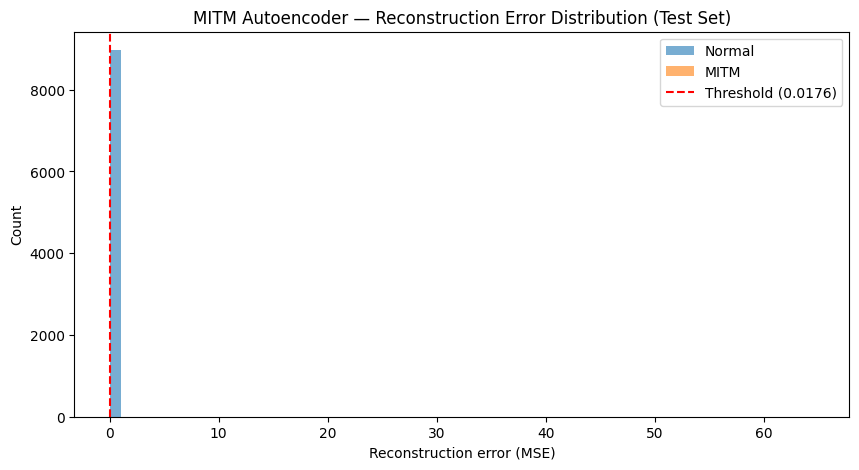

💾 mitm_autoencoder_heldout_metrics.json  |  acc=0.5070  f1=0.0000  auc=nan


/tmp/ipykernel_2091/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


{'model_name': 'mitm_autoencoder_heldout',
 'trained_at': '2026-04-27T18:12:51.540338',
 'threshold': 0.01760231188155004,
 'n_samples': 8981,
 'accuracy': 0.50695913595368,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': nan,
 'pr_auc': 0.0,
 'false_positive_rate': 0.49304086404632,
 'false_negative_rate': 0.0,
 'confusion_matrix': {'tn': 4553, 'fp': 4428, 'fn': 0, 'tp': 0},
 'classification_report': {'0': {'precision': 1.0,
   'recall': 0.50695913595368,
   'f1-score': 0.6728239988177922,
   'support': 8981.0},
  '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
  'accuracy': 0.50695913595368,
  'macro avg': {'precision': 0.5,
   'recall': 0.25347956797684,
   'f1-score': 0.3364119994088961,
   'support': 8981.0},
  'weighted avg': {'precision': 1.0,
   'recall': 0.50695913595368,
   'f1-score': 0.6728239988177922,
   'support': 8981.0}},
 'dataset': 'IoTID20',
 'split': '30% held-out test'}

In [89]:
# ===============================
# MITM HELD-OUT TEST EVALUATION
# ===============================
# Re-uses the test split created in Section 19.
# Produces a classification report, confusion matrix, AUC,
# and a histogram of reconstruction errors.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_true = mitm_y_test.values
errors = mitm_test_errors
y_pred = (errors > threshold).astype(int)

print(f"Test rows: {len(y_true)}  |  Normal: {int((y_true==0).sum())}  |  MITM: {int((y_true==1).sum())}")
print(classification_report(y_true, y_pred, target_names=["Normal", "MITM"]))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_true, errors):.4f}")

# Distribution plot
plt.figure(figsize=(10, 5))
plt.hist(errors[y_true == 0], bins=60, alpha=0.6, label="Normal")
plt.hist(errors[y_true == 1], bins=60, alpha=0.6, label="MITM")
plt.axvline(threshold, linestyle="--", color="red", label=f"Threshold ({threshold:.4f})")
plt.legend()
plt.title("MITM Autoencoder — Reconstruction Error Distribution (Test Set)")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.show()

# Save a separate metrics file for the held-out evaluation
evaluate_and_save(
    "mitm_autoencoder_heldout",
    y_true=y_true, y_prob=errors, y_pred=y_pred,
    threshold=threshold,
    extra={"dataset": "IoTID20", "split": "30% held-out test"},
)


## 21. MITM — Inference & Deployment Test

Smoke tests the saved MITM artifacts on a small batch to confirm they load and score correctly.


In [90]:
import pandas as pd
import numpy as np
import json
import joblib
import tensorflow as tf
import logging

# -------------------------------
# Setup logging
# -------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler("inference.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

# -------------------------------
# Load saved artifacts
# -------------------------------
logger.info("Loading trained artifacts...")

autoencoder = tf.keras.models.load_model("mitm_autoencoder.keras")
scaler = joblib.load("mitm_scaler.pkl")

with open("mitm_config.json", "r") as f:
    config = json.load(f)

threshold = config["threshold"]
feature_columns = config["feature_columns"]

# You can tune this multiplier later
malicious_multiplier = 2.0
malicious_threshold = threshold * malicious_multiplier

logger.info(f"Loaded threshold: {threshold}")
logger.info(f"Loaded malicious threshold: {malicious_threshold}")
logger.info(f"Loaded {len(feature_columns)} feature columns")

# -------------------------------
# Helper: preprocess any file
# -------------------------------
def load_and_prepare_file(file_path: str):
    logger.info(f"Loading file: {file_path}")

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    drop_cols = [
        "Flow ID",
        "Source IP",
        "Source Port",
        "Destination IP",
        "Destination Port",
        "Timestamp"
    ]

    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    actual_label_column = None
    candidate_label_cols = ["Label", "label", "Cat", "attack_type", "Class", "classification"]
    for col in candidate_label_cols:
        if col in df.columns:
            actual_label_column = col
            break

    if actual_label_column:
        logger.info(f"Identified label column: '{actual_label_column}'")
        df["label_binary"] = (df[actual_label_column].astype(str).str.strip().str.lower() != "benign").astype(int)
        cols_to_drop_for_X = [actual_label_column, "label_binary"]
    else:
        logger.warning("No suitable label column found. Creating a dummy 'label_binary' column (all 0s) and not dropping any original label column for feature extraction.")
        df["label_binary"] = pd.Series(0, index=df.index, name="label_binary")
        cols_to_drop_for_X = ["label_binary"]

    X = df.drop(columns=[c for c in cols_to_drop_for_X if c in df.columns])
    X = X.select_dtypes(include=[np.number])

    # Ensure all feature_columns are present, fill missing with 0
    missing_cols = set(feature_columns) - set(X.columns)
    for c in missing_cols:
        X[c] = 0
    X = X[feature_columns] # exact training column order

    return df, X, actual_label_column # Return original df (with label_binary), prepared features, and the identified label column name

# -------------------------------
# Helper: classify by 3 levels
# -------------------------------
def classify_error(error):
    if error <= threshold:
        return "Normal"
    elif error <= malicious_threshold:
        return "Suspicious"
    else:
        return "Malicious"

# -------------------------------
# Main detection function
# -------------------------------
def detect_anomaly(input_df: pd.DataFrame):
    logger.info("Starting anomaly detection...")

    input_df = input_df.copy()
    # Check if all feature_columns are present in input_df, if not, fill missing with 0
    missing_cols = set(feature_columns) - set(input_df.columns)
    for c in missing_cols:
        input_df[c] = 0
    input_df = input_df[feature_columns]

    logger.info(f"Input shape before scaling: {input_df.shape}")

    X_scaled = scaler.transform(input_df)
    logger.info("Scaling complete")

    reconstructed = autoencoder(X_scaled, training=False).numpy()
    logger.info("Autoencoder prediction complete")

    errors = np.mean(np.square(X_scaled - reconstructed), axis=1)

    predictions = [classify_error(err) for err in errors]

    results = pd.DataFrame({
        "reconstruction_error": errors,
        "normal_threshold": threshold,
        "malicious_threshold": malicious_threshold,
        "prediction": predictions
    })

    logger.info("Detection completed")
    return results

# -------------------------------
# Test any file
# Change this filename whenever you want
# -------------------------------
test_file = "IoT Network Intrusion Dataset.csv"

df_test, X_test, identified_label_column = load_and_prepare_file(test_file)

print("Label distribution in selected file:")
if identified_label_column:
    print(df_test[identified_label_column].value_counts())
else:
    print("No original label column found to show distribution. 'label_binary' is all 0s.")

# -------------------------------
# Test random rows
# -------------------------------
sample_random = X_test.sample(10, random_state=42)
result_random = detect_anomaly(sample_random)

print("\nRandom sample results:")
print(result_random)

# -------------------------------
# Test only BENIGN rows
# -------------------------------
df_benign = pd.DataFrame() # Initialize as empty
if identified_label_column:
    df_benign = df_test[df_test[identified_label_column].astype(str).str.strip().str.lower() == "benign"].copy()
else:
    logger.info("Skipping BENIGN-only test as no original label column was identified.")

if not df_benign.empty:
    X_benign = df_benign.drop(columns=[c for c in [identified_label_column, "label_binary"] if c in df_benign.columns])
    X_benign = X_benign.select_dtypes(include=[np.number])
    # Ensure all feature_columns are present, fill missing with 0
    missing_cols = set(feature_columns) - set(X_benign.columns)
    for c in missing_cols:
        X_benign[c] = 0
    X_benign = X_benign[feature_columns]

    benign_sample = X_benign.sample(min(10, len(X_benign)), random_state=42)
    benign_results = detect_anomaly(benign_sample)

    print("\nBenign-only sample results:")
    print(benign_results)

# -------------------------------
# Test only ATTACK rows
# -------------------------------
df_attack = pd.DataFrame() # Initialize as empty
if identified_label_column:
    df_attack = df_test[df_test[identified_label_column].astype(str).str.strip().str.lower() != "benign"].copy()
else:
    logger.info("Skipping ATTACK-only test as no original label column was identified.")

if not df_attack.empty:
    X_attack = df_attack.drop(columns=[c for c in [identified_label_column, "label_binary"] if c in df_attack.columns])
    X_attack = X_attack.select_dtypes(include=[np.number])
    # Ensure all feature_columns are present, fill missing with 0
    missing_cols = set(feature_columns) - set(X_attack.columns)
    for c in missing_cols:
        X_attack[c] = 0
    X_attack = X_attack[feature_columns]

    attack_sample = X_attack.sample(min(10, len(X_attack)), random_state=42)
    attack_results = detect_anomaly(attack_sample)

    print("\nAttack-only sample results:")
    print(attack_results)

    print("\nAttack labels sampled from this file:")
    if identified_label_column:
        print(df_attack[identified_label_column].value_counts())
    else:
        print("No original label column found to print attack labels.")

Label distribution in selected file:
Label
Anomaly    232778
Normal      15927
Name: count, dtype: int64

Random sample results:
   reconstruction_error  normal_threshold  malicious_threshold  prediction
0              0.013924          0.017602             0.035205      Normal
1             60.379091          0.017602             0.035205   Malicious
2             83.070569          0.017602             0.035205   Malicious
3              0.023128          0.017602             0.035205  Suspicious
4              0.121922          0.017602             0.035205   Malicious
5              0.014602          0.017602             0.035205      Normal
6            590.458503          0.017602             0.035205   Malicious
7              0.049206          0.017602             0.035205   Malicious
8            143.625321          0.017602             0.035205   Malicious
9              0.055911          0.017602             0.035205   Malicious

Attack-only sample results:
   reconstruction

## 22. Continuous Learning — Retraining Service

Background service that retrains the supervised + anomaly models when enough new feedback labels have accumulated. Exposes `retrain_models()`, `retrain_check()`, `retrain_auto()`, and `get_retrain_history()`.


In [91]:
# =========================================================
# CONTINUOUS LEARNING PIPELINE (COLAB VERSION)
# =========================================================

import os
import json
import uuid
import sqlite3
from datetime import datetime

import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# =========================================================
# CONFIG (COLAB FRIENDLY)
# =========================================================
BASE_DIR = "/content"
DB_NAME = os.path.join(BASE_DIR, "sam_ads.db")

MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

RF_MODEL_PATH = os.path.join(BASE_DIR, "rf_model.pkl")
ISO_MODEL_PATH = os.path.join(BASE_DIR, "iso_model.pkl")
FEATURE_COLUMNS_PATH = os.path.join(BASE_DIR, "feature_columns.pkl")
MODEL_REGISTRY_PATH = os.path.join(BASE_DIR, "model_registry.json")

MIN_LABELS_TO_RETRAIN = 30


# =========================================================
# DB HELPERS
# =========================================================
def get_connection():
    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row
    return conn




# =========================================================
# FEATURE EXTRACTION  -- now reuses cell 18's builder
# =========================================================
def safe_load_feature_columns():
    """Loads feature_columns saved by cell 18. No hardcoded fallback list
    (that would drift from the trained model)."""
    if os.path.exists(FEATURE_COLUMNS_PATH):
        return joblib.load(FEATURE_COLUMNS_PATH)
    raise FileNotFoundError(
        f"{FEATURE_COLUMNS_PATH} not found. Run cell 18 first."
    )


def extract_features_from_row(row, feature_columns):
    """Reuses build_request_features from cell 18 so retraining produces
    the same columns as the original training run."""
    headers_blob = row["headers"] if "headers" in row.keys() else ""
    headers = {}
    try:
        if headers_blob:
            headers = json.loads(headers_blob) if isinstance(headers_blob, str) else dict(headers_blob)
    except Exception:
        headers = {}

    qp_blob = row["query_params"] if "query_params" in row.keys() else ""
    qp = {}
    try:
        if qp_blob:
            qp = json.loads(qp_blob) if isinstance(qp_blob, str) else dict(qp_blob)
    except Exception:
        qp = {}

    feats = build_request_features(
        path=str(row["path"] or ""),
        payload=str(row["payload"] or ""),
        query_params=qp,
        headers=headers,
        method=str(row["method"] or "GET"),
        user_agent=headers.get("user-agent", "") if isinstance(headers, dict) else "",
    )
    return {col: feats.get(col, 0) for col in feature_columns}


# =========================================================
# LABEL MAPPING
# =========================================================
def map_label_to_binary(label):
    label = str(label or "").strip().lower()
    if label == "normal":
        return 0
    if label in ["malicious", "suspicious"]:
        return 1
    return None


# =========================================================
# INSERT / SAVE FEEDBACK
# =========================================================
def save_feedback_label(log_id, admin_label, feedback_notes=""):
    conn = None
    try:
        if not log_id or not admin_label:
            return {"success": False, "error": "Missing log_id or admin_label"}

        admin_label = admin_label.strip().lower()
        if admin_label not in ["normal", "suspicious", "malicious"]:
            return {"success": False, "error": "Invalid label"}

        conn = get_connection()
        cursor = conn.cursor()

        cursor.execute("""
            SELECT predicted_class
            FROM api_logs
            WHERE id = ?
        """, (log_id,))
        row = cursor.fetchone()

        if not row:
            return {"success": False, "error": "Log not found"}

        original_label = row["predicted_class"]

        cursor.execute("""
            INSERT INTO feedback_labels (
                feedback_id, log_id, original_label, admin_label,
                feedback_notes, created_at, used_in_training
            )
            VALUES (?, ?, ?, ?, ?, ?, 0)
        """, (
            str(uuid.uuid4()),
            log_id,
            original_label,
            admin_label,
            feedback_notes,
            datetime.utcnow().isoformat()
        ))

        conn.commit()
        return {"success": True, "message": "Label saved successfully"}

    except sqlite3.Error as e:
        return {"success": False, "error": "Database error", "details": str(e)}
    except Exception as e:
        return {"success": False, "error": "Unexpected error", "details": str(e)}
    finally:
        if conn:
            conn.close()


# =========================================================
# BUILD TRAINING DATASET
# =========================================================
def load_feedback_dataset():
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT
            l.id,
            l.method,
            l.path,
            l.payload,
            l.query_params,
            l.predicted_class,
            f.admin_label,
            f.used_in_training
        FROM api_logs l
        INNER JOIN feedback_labels f ON l.id = f.log_id
        WHERE f.admin_label IS NOT NULL
    """)

    rows = cursor.fetchall()
    conn.close()

    if not rows:
        return pd.DataFrame()

    feature_columns = safe_load_feature_columns()

    records = []
    for row in rows:
        feats = extract_features_from_row(row, feature_columns)
        label_binary = map_label_to_binary(row["admin_label"])

        if label_binary is None:
            continue

        feats["log_id"] = row["id"]
        feats["target"] = label_binary
        feats["admin_label"] = row["admin_label"]
        feats["used_in_training"] = row["used_in_training"]
        records.append(feats)

    return pd.DataFrame(records)


# =========================================================
# MODEL REGISTRY
# =========================================================
def load_model_registry():
    if os.path.exists(MODEL_REGISTRY_PATH):
        with open(MODEL_REGISTRY_PATH, "r", encoding="utf-8") as f:
            return json.load(f)

    return {
        "random_forest": {"version": "v1", "path": RF_MODEL_PATH, "updated_at": None},
        "isolation_forest": {"version": "v1", "path": ISO_MODEL_PATH, "updated_at": None}
    }


def save_model_registry(registry):
    with open(MODEL_REGISTRY_PATH, "w", encoding="utf-8") as f:
        json.dump(registry, f, indent=2)


# =========================================================
# RETRAINING PIPELINE
# =========================================================
def retrain_models():
    df = load_feedback_dataset()

    if df.empty:
        return {"success": False, "message": "No feedback labels found"}

    if len(df) < MIN_LABELS_TO_RETRAIN:
        return {
            "success": False,
            "message": f"Not enough labeled data. Current: {len(df)}, required: {MIN_LABELS_TO_RETRAIN}"
        }

    training_run_id = str(uuid.uuid4())
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        INSERT INTO model_training_runs (training_run_id, started_at, status)
        VALUES (?, ?, ?)
    """, (training_run_id, datetime.utcnow().isoformat(), "running"))
    conn.commit()

    try:
        feature_columns = safe_load_feature_columns()

        X = df[feature_columns]
        y = df["target"]

        print("Training label distribution:")
        print(y.value_counts())

        if len(np.unique(y)) < 2:
            raise ValueError(
                "Training failed because y contains only one class. "
                "You need both normal and malicious/suspicious labels."
            )

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        rf_model = RandomForestClassifier(
            n_estimators=150, random_state=42,
            class_weight="balanced", n_jobs=-1
        )
        rf_model.fit(X_train, y_train)

        y_pred = rf_model.predict(X_test)
        acc = float(accuracy_score(y_test, y_pred))
        report = classification_report(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        print("\nModel classes:", rf_model.classes_)
        print("\nAccuracy:", acc)
        print("\nClassification Report:\n", report)
        print("\nConfusion Matrix:\n", cm)

        normal_only = X_train[y_train == 0]
        if len(normal_only) == 0:
            raise ValueError("Isolation Forest training failed: no normal samples.")

        iso_model = IsolationForest(
            n_estimators=100, contamination=0.2, random_state=42
        )
        iso_model.fit(normal_only)

        version_time = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
        rf_model_file = os.path.join(MODEL_DIR, f"rf_model_{version_time}.pkl")
        iso_model_file = os.path.join(MODEL_DIR, f"iso_model_{version_time}.pkl")

        joblib.dump(rf_model, rf_model_file)
        joblib.dump(iso_model, iso_model_file)
        joblib.dump(rf_model, RF_MODEL_PATH)
        joblib.dump(iso_model, ISO_MODEL_PATH)
        joblib.dump(feature_columns, FEATURE_COLUMNS_PATH)

        registry = load_model_registry()
        registry["random_forest"] = {
            "version": f"rf_{version_time}",
            "path": rf_model_file,
            "updated_at": datetime.utcnow().isoformat(),
            "accuracy": acc
        }
        registry["isolation_forest"] = {
            "version": f"iso_{version_time}",
            "path": iso_model_file,
            "updated_at": datetime.utcnow().isoformat()
        }
        save_model_registry(registry)

        cursor.execute("""
            UPDATE feedback_labels
            SET used_in_training = 1
            WHERE used_in_training = 0
        """)

        cursor.execute("""
            UPDATE model_training_runs
            SET finished_at = ?, training_rows = ?, validation_rows = ?,
                rf_model_file = ?, iso_model_file = ?, accuracy = ?,
                status = ?, notes = ?
            WHERE training_run_id = ?
        """, (
            datetime.utcnow().isoformat(),
            int(len(X_train)),
            int(len(X_test)),
            rf_model_file,
            iso_model_file,
            acc,
            "completed",
            report,
            training_run_id
        ))

        conn.commit()
        conn.close()

        return {
            "success": True,
            "message": "Models retrained successfully",
            "training_run_id": training_run_id,
            "accuracy": acc,
            "rf_model_file": rf_model_file,
            "iso_model_file": iso_model_file
        }

    except Exception as e:
        cursor.execute("""
            UPDATE model_training_runs
            SET finished_at = ?, status = ?, notes = ?
            WHERE training_run_id = ?
        """, (datetime.utcnow().isoformat(), "failed", str(e), training_run_id))
        conn.commit()
        conn.close()

        return {"success": False, "message": "Retraining failed", "details": str(e)}


# =========================================================
# AUTO MODEL UPDATE CHECK
# =========================================================
def retrain_check():
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT COUNT(*) AS unlabeled_count
        FROM feedback_labels
        WHERE used_in_training = 0
    """)
    unlabeled_count = cursor.fetchone()["unlabeled_count"] or 0
    conn.close()

    should_retrain = unlabeled_count >= MIN_LABELS_TO_RETRAIN

    return {
        "success": True,
        "unlabeled_feedback_count": unlabeled_count,
        "minimum_required": MIN_LABELS_TO_RETRAIN,
        "should_retrain": should_retrain
    }


def retrain_auto():
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT COUNT(*) AS unlabeled_count
        FROM feedback_labels
        WHERE used_in_training = 0
    """)
    unlabeled_count = cursor.fetchone()["unlabeled_count"] or 0
    conn.close()

    if unlabeled_count < MIN_LABELS_TO_RETRAIN:
        return {
            "success": False,
            "message": f"Auto retrain skipped. Need at least {MIN_LABELS_TO_RETRAIN} new feedback labels."
        }

    return retrain_models()


# =========================================================
# TRAINING HISTORY
# =========================================================
def get_retrain_history(limit=20):
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT *
        FROM model_training_runs
        ORDER BY datetime(started_at) DESC
        LIMIT ?
    """, (limit,))
    rows = cursor.fetchall()
    conn.close()

    return {"success": True, "data": [dict(row) for row in rows]}

## 23. Runtime — Live Feature Extraction

Lightweight wrapper used by the proxy at request time to turn an HTTP request into the exact feature vector expected by the trained models.


In [92]:
# ===============================
# SECTION 23: LIVE FEATURE EXTRACTION (OPTIMIZED)
# ===============================
# Now just a thin wrapper around the SAME build_request_features defined
# in the training cell (Section 9). This guarantees zero feature drift
# between training and inference, which was a real bug source in the
# previous version (training included header_text in full_request, the
# live builder did slightly different normalization).
#
# The build_request_features function is defined in cell 18 and is
# imported here via the global namespace.

import pandas as pd

# feature_columns is loaded in section 24.1 from disk
def extract_features(body_text: str, query_params: dict, headers: dict,
                     method: str, path: str):
    """
    Returns (X_live, features_dict). X_live is a 1-row DataFrame aligned
    to the saved feature_columns ordering.
    """
    feats = build_request_features(
        path=path,
        payload=body_text,
        query_params=query_params,
        headers=headers,
        method=method,
        user_agent=headers.get("user-agent", ""),
    )
    # Ensure every expected column exists, in order
    row = {c: feats.get(c, 0) for c in feature_columns}
    X_live = pd.DataFrame([row])[feature_columns].fillna(0)
    return X_live, feats


## 24. Runtime — Proxy Server

The proxy is the main runtime component. It's split into focused sub-cells that must be run in order.

| Sub-section | Purpose |
|---|---|
| 24.1 | Load trained model artifacts |
| 24.2 | Initialize FastAPI app, session store, and config constants |
| 24.3 | Small utility helpers (hashing, fingerprints, header filtering) |
| 24.4 | Request feature extraction helpers |
| 24.5 | Session behavior analysis + default result objects |
| 24.6 | `predict_request` — the main inference function |
| 24.7 | FastAPI routes (including the main proxy handler) |
| 24.8 | Logging (alerts, CSV, SQLite) |
| 24.9 | Email alert delivery |


### 24.1 Load Model Artifacts


In [93]:
# -----------------------------------
# Load artifacts
# -----------------------------------
rf_model = joblib.load("rf_model.pkl")
iso_model = joblib.load("iso_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")
rf_threshold = joblib.load("rf_threshold.pkl")
iso_threshold = joblib.load("iso_threshold.pkl")

if os.path.exists("model_registry.json"):
    with open("model_registry.json", "r", encoding="utf-8") as f:
        model_registry = json.load(f)
else:
    model_registry = {
        "random_forest": {
            "version": "rf_v1",
            "threshold": float(rf_threshold),
            "feature_file": "feature_columns.pkl"
        },
        "isolation_forest": {
            "version": "iso_v1",
            "threshold": float(iso_threshold)
        },
        "session_behavior": {
            "version": "session_behavior_v1",
            "threshold": 25.0
        }
    }

### 24.2 App Initialization, Session Store & Config


In [94]:
nest_asyncio.apply()
app = FastAPI()

# Add CORS middleware here, before the app starts
from fastapi.middleware.cors import CORSMiddleware

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# -----------------------------------
# Optional engines from earlier cells
# -----------------------------------
rule_engine = RuleBasedDetectionEngine() if "RuleBasedDetectionEngine" in globals() else None


# -----------------------------------
# Runtime session tracking
# -----------------------------------
SESSION_STORE = defaultdict(lambda: {
    "first_seen": None,
    "last_seen": None,
    "ip_history": deque(maxlen=10),
    "user_agent_history": deque(maxlen=10),
    "endpoint_history": deque(maxlen=20),
    "request_fingerprints": deque(maxlen=50),
    "fingerprint_times": {},
    "replay_count": 0,
    "hijack_score": 0.0
})

REPLAY_WINDOW_SECONDS = 60
SEQUENCE_WINDOW = 5

logs = []

# -----------------------------------
# Config
# -----------------------------------
BACKEND_BASE_URL = "http://127.0.0.1:8001"
REQUEST_TIMEOUT = 30.0
LOG_CSV_FILE = "sam_ads_logs.csv"
SQLITE_DB_FILE = "sam_ads.db"

### 24.3 Utility Helpers

Token hashing, session-ID construction, request fingerprints, and header filtering used throughout the proxy.


In [95]:
# -----------------------------------
# Helper functions (proxy-only; patterns live in cell 18)
# -----------------------------------
def should_trigger_alert(log_entry):
    return (
         log_entry.get("predicted_class") in ("malicious", "suspicious")
        or int(log_entry.get("replay_flag", 0)) == 1
        or float(log_entry.get("hijack_score", 0.0)) >= 50.0
    )


def hash_token(token):
    if not token:
        return None
    return hashlib.sha256(token.encode("utf-8")).hexdigest()


def build_session_id(headers: dict, client_ip: str):
    auth_token = headers.get("authorization")
    cookie = headers.get("cookie", "")
    user_agent = headers.get("user-agent", "")
    token_hash = hash_token(auth_token)

    if token_hash:
        return f"token::{token_hash}"
    if cookie:
        cookie_hash = hashlib.sha256(cookie.encode("utf-8")).hexdigest()
        return f"cookie::{cookie_hash}"

    fallback = f"{client_ip}|{user_agent}"
    return f"anon::{hashlib.sha256(fallback.encode('utf-8')).hexdigest()}"


def build_request_fingerprint(method, path, query_params, body_text, token_hash):
    raw = json.dumps(
        {"method": method, "path": path, "query_params": query_params,
         "body_text": body_text, "token_hash": token_hash},
        sort_keys=True, default=str,
    )
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()


def filter_request_headers(headers: dict) -> dict:
    excluded = {"host", "content-length", "connection"}
    return {k: v for k, v in headers.items() if k.lower() not in excluded}


def filter_response_headers(headers: dict) -> dict:
    excluded = {"content-encoding", "transfer-encoding", "connection"}
    return {k: v for k, v in headers.items() if k.lower() not in excluded}


def normalize_rule_risk(rule_risk_score):
    try:
        score = float(rule_risk_score)
    except Exception:
        return 0.0
    if score > 1.0:
        return min(score / 100.0, 1.0)
    return max(0.0, min(score, 1.0))


# Sanity: confirm we are still using the GOOD patterns from cell 18
assert callable(clean_text), "clean_text not defined — run cell 18 first"
assert isinstance(SQL_PATTERNS, list), "SQL_PATTERNS missing — run cell 18 first"
assert any("information_schema" in p for p in SQL_PATTERNS), \
    "Wrong SQL_PATTERNS in scope — make sure cell 18 ran"
print("Proxy helpers OK; using patterns from cell 18.")


Proxy helpers OK; using patterns from cell 18.


### 24.4 Request Feature Extraction

Turns the parsed HTTP request into the numeric feature vector the trained models expect.


In [96]:
# ===============================
# SECTION 24.4: LIVE FEATURE EXTRACTION (sanity check only)
# ===============================
# extract_features() is defined in cell 46. This cell just verifies wiring.

assert callable(build_request_features), "Run cell 18 first"
assert callable(extract_features), "Run cell 46 first"
assert isinstance(feature_columns, list), "Run cell 18 first"

_t = build_request_features(
    path="/files",
    query_params={"id": "1 UNION SELECT password"},
    headers={"user-agent": "sqlmap/1.0"},
    method="GET",
)
print("Sanity (attack):", {
    "sql_pattern_hits": _t["sql_pattern_hits"],
    "bad_ua_pattern_hits": _t["bad_ua_pattern_hits"],
})
assert _t["sql_pattern_hits"] >= 1
assert _t["bad_ua_pattern_hits"] >= 1

_b = build_request_features(
    path="/files",
    headers={"user-agent": "python-requests/2.32.4"},
    method="GET",
)
print("Sanity (benign):", {
    "sql_pattern_hits": _b["sql_pattern_hits"],
    "xss_pattern_hits": _b["xss_pattern_hits"],
    "cmd_pattern_hits": _b["cmd_pattern_hits"],
})
assert _b["sql_pattern_hits"] == 0, "FALSE POSITIVE on benign /files"
assert _b["xss_pattern_hits"] == 0
assert _b["cmd_pattern_hits"] == 0
print("Live feature extraction OK — benign stays clean.")


Sanity (attack): {'sql_pattern_hits': 1, 'bad_ua_pattern_hits': 1}
Sanity (benign): {'sql_pattern_hits': 0, 'xss_pattern_hits': 0, 'cmd_pattern_hits': 0}
Live feature extraction OK — benign stays clean.


### 24.5 Session Behavior Analysis & Default Results


In [97]:
def analyze_session_behavior(
    session_id: str,
    token_hash: str,
    client_ip: str,
    user_agent: str,
    method: str,
    path: str,
    query_params: dict,
    body_text: str
):
    now = time.time()
    session = SESSION_STORE[session_id]

    if session["first_seen"] is None:
        session["first_seen"] = now
    session["last_seen"] = now

    request_fingerprint = build_request_fingerprint(
        method=method,
        path=path,
        query_params=query_params,
        body_text=body_text,
        token_hash=token_hash
    )

    replay_flag = 0
    ip_changed = 0
    user_agent_changed = 0
    sequence_anomaly = 0
    hijack_score = 0.0
    mitm_reasons = []

    # Replay detection
    if request_fingerprint in session["fingerprint_times"]:
        last_seen = session["fingerprint_times"][request_fingerprint]
        if now - last_seen <= REPLAY_WINDOW_SECONDS:
            replay_flag = 1
            session["replay_count"] += 1
            hijack_score += 35.0
            mitm_reasons.append("replayed request fingerprint within short time window")

    session["fingerprint_times"][request_fingerprint] = now
    session["request_fingerprints"].append(request_fingerprint)

    # IP change
    if len(session["ip_history"]) > 0 and client_ip not in session["ip_history"]:
        ip_changed = 1
        hijack_score += 20.0
        mitm_reasons.append("session used from new ip")

    session["ip_history"].append(client_ip)

    # User-Agent change
    if len(session["user_agent_history"]) > 0 and user_agent not in session["user_agent_history"]:
        user_agent_changed = 1
        hijack_score += 20.0
        mitm_reasons.append("session used from new user-agent")

    session["user_agent_history"].append(user_agent)

    # Sequence anomaly
    sensitive_keywords = ["admin", "delete", "update", "config", "users", "export"]
    recent_endpoints = list(session["endpoint_history"])

    if any(k in path.lower() for k in sensitive_keywords):
        if len(recent_endpoints) == 0:
            sequence_anomaly = 1
            hijack_score += 20.0
            mitm_reasons.append("sensitive endpoint accessed without prior session flow")

    if len(recent_endpoints) >= 2:
        if path not in recent_endpoints[-SEQUENCE_WINDOW:] and any(k in path.lower() for k in sensitive_keywords):
            sequence_anomaly = 1
            hijack_score += 15.0
            mitm_reasons.append("abrupt endpoint jump in session flow")

    session["endpoint_history"].append(path)
    session["hijack_score"] = hijack_score

    if hijack_score >= 60:
        mitm_behavior_class = "malicious"
    elif hijack_score >= 25:
        mitm_behavior_class = "suspicious"
    else:
        mitm_behavior_class = "normal"

    return {
        "session_id": session_id,
        "request_fingerprint": request_fingerprint,
        "replay_flag": replay_flag,
        "replay_count": session["replay_count"],
        "ip_changed": ip_changed,
        "user_agent_changed": user_agent_changed,
        "sequence_anomaly": sequence_anomaly,
        "hijack_score": hijack_score,
        "mitm_behavior_class": mitm_behavior_class,
        "mitm_reasons": mitm_reasons
    }


def default_rule_result():
    return {
        "decision": "allow",
        "label": "normal",
        "risk_score": 0.0,
        "reasons": []
    }




### 24.6 `predict_request` — Main Inference Function

Combines the RF + ISO + rule + MITM signals into a single decision. This is the function the proxy route calls for every incoming request.


In [98]:
def predict_request(X_live, features, headers, body_text, method, path,
                    query_params, client_ip):
    user_agent = headers.get("user-agent", "") or ""
    auth_token = headers.get("authorization")
    token_hash = hash_token(auth_token)
    session_id = build_session_id(headers, client_ip)

    # ---- SIGNAL CLASSIFICATION ----
    # Strong attack indicator — full pattern match
    has_strong_signal = (
        features.get("sql_pattern_hits", 0) > 0
        or features.get("xss_pattern_hits", 0) > 0
        or features.get("cmd_pattern_hits", 0) > 0
        or features.get("traversal_pattern_hits", 0) > 0
        or features.get("bad_ua_pattern_hits", 0) > 0
    )

    # Weak signal — suspicious chars or SQL keywords without full pattern
    sql_keywords_weak = ["select", "union", "drop", "insert", "delete", "update"]
    combined_text = f"{path} {body_text} {' '.join(str(v) for v in (query_params or {}).values())}".lower()
    has_weak_keyword = any(k in combined_text for k in sql_keywords_weak)

    has_weak_signal = (
        features.get("special_char_count", 0) >= 1
        or features.get("percent_count", 0) >= 2
        or has_weak_keyword
    )

    # Truly clean: zero strong AND zero weak signals
    no_attack_indicators = not has_strong_signal and not has_weak_signal

    # ---- 1. Random Forest ----
    try:
        classes = list(rf_model.classes_)
        idx = classes.index(1) if 1 in classes else 1
        rf_score = float(rf_model.predict_proba(X_live)[0][idx])
    except Exception:
        rf_score = 0.0

    # If features are clean, OVERRIDE the model
    if no_attack_indicators:
        rf_score = 0.0
    elif has_weak_signal and not has_strong_signal:
        # Weak signal only — clamp model output into suspicious zone
        # (caps at suspicious, never reaches block by itself)
        rf_score = max(0.50, min(rf_score, 0.55))

    # ---- 2. Isolation Forest ----
    try:
        iso_raw = float(-iso_model.score_samples(X_live)[0])
    except Exception:
        iso_raw = 0.0
    iso_flag = int(iso_raw >= iso_threshold) and not no_attack_indicators
    iso_norm = max(0.0, min(iso_raw / (iso_threshold + 1e-9), 1.0))
    if no_attack_indicators:
        iso_norm = 0.0

    # ---- 3. Rule engine ----
    if rule_engine is not None:
        rule_result = rule_engine.evaluate_request({
            "client_ip": client_ip, "method": method, "path": path,
            "query_params": query_params, "headers": headers, "body": body_text,
        }) or default_rule_result()
    else:
        rule_result = default_rule_result()
    rule_decision = str(rule_result.get("decision", "allow")).lower()
    rule_label = str(rule_result.get("label", "normal")).lower()
    rule_risk_norm = max(0.0, min(float(rule_result.get("risk_score", 0)) / 100.0, 1.0))
    rule_block = (rule_decision == "block")

    # ---- 4. Session / MITM behavior ----
    session_data = analyze_session_behavior(
        session_id=session_id, token_hash=token_hash, client_ip=client_ip,
        user_agent=user_agent, method=method, path=path,
        query_params=query_params, body_text=body_text,
    )
    replay_flag = int(session_data.get("replay_flag", 0))
    hijack_score = float(session_data.get("hijack_score", 0.0))
    mitm_norm = min(hijack_score / 100.0, 1.0)
    if hijack_score >= 60:
        mitm_class = "malicious"
    elif hijack_score >= 25 or replay_flag:
        mitm_class = "suspicious"
    else:
        mitm_class = "normal"

    # ---- 5. FUSED SCORE ----
    final_score = (
        0.60 * rf_score +
        0.15 * iso_norm +
        0.15 * mitm_norm +
        0.10 * rule_risk_norm
    )
    final_score = max(0.0, min(final_score, 1.0))

    # Weak-signal direct override: if there's a weak signal and no strong one,
    # force final_score into suspicious zone (0.55) regardless of fusion math.
    if has_weak_signal and not has_strong_signal:
        final_score = max(final_score, 0.55)

    # Only escalate when corroborating signal is real
    if rule_block and rf_score >= 0.30:
        final_score = max(final_score, 0.75)
    if mitm_class == "malicious" and rf_score >= 0.30:
        final_score = max(final_score, 0.75)

    # ---- 6. DECISION ----
    BLOCK_THRESHOLD = 0.70
    FLAG_THRESHOLD = 0.50

    if final_score >= BLOCK_THRESHOLD:
        predicted_class, decision = "malicious", "block"
    elif final_score >= FLAG_THRESHOLD:
        predicted_class, decision = "suspicious", "flag"
    else:
        predicted_class, decision = "normal", "allow"

    # ---- 7. Reasons ----
    reasons = []
    if no_attack_indicators:
        reasons.append("no attack indicators present (model bypassed)")
    elif has_weak_signal and not has_strong_signal:
        reasons.append("weak attack signal detected")
    if rf_score >= 0.70:
        reasons.append(f"random forest confident attack (p={rf_score:.2f})")
    elif rf_score >= 0.50:
        reasons.append(f"random forest moderate attack signal (p={rf_score:.2f})")
    if rule_block:
        reasons.extend(rule_result.get("reasons", [])[:2])
    if iso_flag:
        reasons.append("isolation forest anomaly detected")
    if replay_flag:
        reasons.append("request replay detected")
    if mitm_class != "normal":
        reasons.append(f"session behavior {mitm_class} (hijack={hijack_score:.0f})")

    final_reason = "; ".join(dict.fromkeys(reasons)) if reasons else "normal request"

    return {
        "decision": decision,
        "reason": final_reason,
        "predicted_class": predicted_class,
        "confidence": float(final_score),
        "risk_score": float(final_score),
        "supervised_score": float(rf_score),
        "anomaly_flag": int(iso_flag),
        "iso_score": float(iso_raw),
        "iso_score_norm": float(iso_norm),
        "mitm_class": mitm_class,
        "mitm_score": float(mitm_norm),
        "rule_score": float(rule_risk_norm),
        "rule_result": rule_result,
        "session_data": session_data,
        "token_hash": token_hash,
        "session_id": session_id,
        "model_versions": {
            "random_forest_version": "rf_v3_with_guard",
            "isolation_forest_version": "iso_v3_with_guard",
            "session_behavior_version": "session_v3",
        },
        "model_thresholds": {
            "rf_threshold": float(rf_threshold),
            "iso_threshold": float(iso_threshold),
            "flag_threshold": FLAG_THRESHOLD,
            "block_threshold": BLOCK_THRESHOLD,
        },
    }

### 24.7 FastAPI Routes

Includes the health-check root, `/logs` introspection, and the main `/{path:path}` proxy handler that does the security analysis before forwarding to the backend.


In [99]:
@app.get("/")
async def root():
    return {"message": "SAM-ADS proxy is running"}


@app.get("/logs")
async def get_logs():
    return {"total_logs": len(logs), "logs": logs}


@app.api_route(
    "/{path:path}",
    methods=["GET", "POST", "PUT", "DELETE", "PATCH", "OPTIONS", "HEAD"]
)
async def proxy(path: str, request: Request):
    start_time = time.time()

    body = await request.body()
    body_text = body.decode("utf-8", errors="ignore")

    query_params = dict(request.query_params)
    headers = dict(request.headers)
    client_ip = request.client.host if request.client else "unknown"
    auth_token = headers.get("authorization")
    auth_token_hash = hash_token(auth_token)
    cookie_data = headers.get("cookie")
    target_url = f"{BACKEND_BASE_URL.rstrip('/')}/{path}"

    X_live, features = extract_features(
        body_text=body_text,
        query_params=query_params,
        headers=headers,
        method=request.method,
        path=path
    )

    prediction = predict_request(
        X_live=X_live,
        features=features,
        headers=headers,
        body_text=body_text,
        method=request.method,
        path=path,
        query_params=query_params,
        client_ip=client_ip
    )

    decision = prediction["decision"]
    reason = prediction["reason"]
    predicted_class = prediction["predicted_class"]
    supervised_score = prediction["supervised_score"]
    anomaly_flag = prediction["anomaly_flag"]
    mitm_class = prediction["mitm_class"]
    mitm_score = prediction["mitm_score"]
    rule_result = prediction["rule_result"]
    session_data = prediction["session_data"]

    log_entry = {
        "id": str(uuid.uuid4()),
        "timestamp": datetime.utcnow().isoformat(),
        "ip_address": client_ip,
        "method": request.method,
        "path": f"/{path}",
        "backend_url": target_url,
        "headers": headers,
        "payload": body_text,
        "query_params": query_params,
        "user_agent": headers.get("user-agent"),
        "authorization": auth_token,
        "token_hash": prediction["token_hash"],
        "cookie": cookie_data,
        "content_length": len(body),
        "response_time_ms": None,
        "response_status": None,
        "decision": decision,
        "reason": reason,
        "predicted_class": predicted_class,
        "label": predicted_class,
        "supervised_score": float(supervised_score),
        "anomaly_flag": int(anomaly_flag),
        "iso_score": float(prediction["iso_score"]),
        "extracted_features": features,
        "mitm_class": mitm_class,
        "mitm_score": float(mitm_score),
        "rule_decision": rule_result.get("decision"),
        "rule_label": rule_result.get("label"),
        "rule_risk_score": rule_result.get("risk_score"),
        "rule_reasons": rule_result.get("reasons", []),
        "fusion_confidence": prediction["confidence"],
        "fusion_risk_score": prediction["risk_score"],
        "rf_model_version": prediction["model_versions"]["random_forest_version"],
        "iso_model_version": prediction["model_versions"]["isolation_forest_version"],
        "session_behavior_version": prediction["model_versions"]["session_behavior_version"],
        "rf_threshold": prediction["model_thresholds"]["rf_threshold"],
        "iso_threshold": prediction["model_thresholds"]["iso_threshold"],
        "feature_file": model_registry.get("random_forest", {}).get("feature_file", "feature_columns.pkl"),

        # Session fields
        "session_id": session_data["session_id"],
        "request_fingerprint": session_data["request_fingerprint"],
        "replay_flag": int(session_data["replay_flag"]),
        "replay_count": int(session_data["replay_count"]),
        "ip_changed": int(session_data["ip_changed"]),
        "user_agent_changed": int(session_data["user_agent_changed"]),
        "sequence_anomaly": int(session_data["sequence_anomaly"]),
        "hijack_score": float(session_data["hijack_score"]),
        "mitm_reasons": session_data["mitm_reasons"]
    }

    if should_trigger_alert(log_entry):
        try:
            save_alert(log_entry)
        except Exception as e:
            print("Alert save error:", e)

        if "send_email_alert" in globals():
          alert_message = f"""
      API SECURITY ALERT IP: {log_entry.get("ip_address")}
      Endpoint: {log_entry.get("path")}
      Method: {log_entry.get("method")}
      Class: {log_entry.get("predicted_class")}
      Decision: {log_entry.get("decision")}
      Replay: {log_entry.get("replay_flag")}
      Hijack Score: {log_entry.get("hijack_score")}
      Reason: {log_entry.get("reason")}
      """
          try:
              send_email_alert(
                  subject="API Sentinel Alert",
                  body=alert_message,
                  severity = map_severity(log_entry["predicted_class"]),
                  trigger=log_entry.get("reason", ""),
                  ip_address=log_entry.get("ip_address", ""),
                  endpoint=log_entry.get("path", ""),
                  method=log_entry.get("method", ""),           # ← new
                  user_agent=log_entry.get("user_agent", ""),   # ← new
                  risk_score=log_entry.get("fusion_risk_score", 0.0),
              )
          except Exception as e:
              print("Email alert error:", e)
    try:
        async with httpx.AsyncClient(timeout=REQUEST_TIMEOUT, follow_redirects=True) as client:
            backend_response = await client.request(
                method=request.method,
                url=target_url,
                headers=filter_request_headers(headers),
                params=query_params,
                content=body
            )

        response_time_ms = round((time.time() - start_time) * 1000, 2)
        log_entry["response_time_ms"] = response_time_ms
        log_entry["response_status"] = backend_response.status_code

        logs.append(log_entry)
        save_log_to_csv(log_entry)
        save_log_to_sqlite(log_entry)

        print("=== Security Log Entry ===")
        print(json.dumps(log_entry, indent=2, default=str))

        return Response(
            content=backend_response.content,
            status_code=backend_response.status_code,
            headers=filter_response_headers(dict(backend_response.headers)),
            media_type=backend_response.headers.get("content-type")
        )

    except httpx.RequestError as e:
        response_time_ms = round((time.time() - start_time) * 1000, 2)
        log_entry["response_time_ms"] = response_time_ms
        log_entry["response_status"] = 502
        log_entry["decision"] = "error"
        log_entry["reason"] = f"backend forwarding failed: {str(e)}"

        logs.append(log_entry)
        save_log_to_csv(log_entry)
        save_log_to_sqlite(log_entry)

        print("=== Security Log Entry ===")
        print(json.dumps(log_entry, indent=2, default=str))

        return JSONResponse(
            content={
                "message": "Backend request failed",
                "decision": "error",
                "reason": str(e)
            },
            status_code=502
        )


### 24.8 Logging — Alerts, CSV, SQLite


In [100]:
def save_alert(log_entry):
    try:
        if "get_connection" in globals():
            conn = get_connection()
        else:
            conn = sqlite3.connect(SQLITE_DB_FILE)

        cursor = conn.cursor()
        cursor.execute("""
            INSERT INTO alerts (
                log_id, timestamp, ip_address, path,
                attack_type, severity, decision, message
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            log_entry["id"],
            log_entry["timestamp"],
            log_entry["ip_address"],
            log_entry["path"],
            log_entry["predicted_class"],
            "HIGH" if log_entry["predicted_class"] == "malicious" else "MEDIUM",
            log_entry["decision"],
            log_entry["reason"]
        ))
        conn.commit()
        conn.close()
    except Exception as e:
        print("save_alert error:", e)


def save_log_to_csv(log_entry):
    file_exists = os.path.isfile(LOG_CSV_FILE)

    row = {
        "id": log_entry.get("id"),
        "timestamp": log_entry.get("timestamp"),
        "ip_address": log_entry.get("ip_address"),
        "method": log_entry.get("method"),
        "path": log_entry.get("path"),
        "backend_url": log_entry.get("backend_url"),
        "user_agent": log_entry.get("user_agent"),
        "authorization": log_entry.get("authorization"),
        "token_hash": log_entry.get("token_hash"),
        "cookie": log_entry.get("cookie"),
        "content_length": log_entry.get("content_length"),
        "response_time_ms": log_entry.get("response_time_ms"),
        "response_status": log_entry.get("response_status"),
        "decision": log_entry.get("decision"),
        "reason": log_entry.get("reason"),
        "predicted_class": log_entry.get("predicted_class"),
        "label": log_entry.get("label"),
        "supervised_score": log_entry.get("supervised_score"),
        "anomaly_flag": log_entry.get("anomaly_flag"),
        "iso_score": log_entry.get("iso_score"),
        "mitm_class": log_entry.get("mitm_class"),
        "mitm_score": log_entry.get("mitm_score"),
        "rule_decision": log_entry.get("rule_decision"),
        "rule_label": log_entry.get("rule_label"),
        "rule_risk_score": log_entry.get("rule_risk_score"),
        "rule_reasons": json.dumps(log_entry.get("rule_reasons", [])),
        "fusion_confidence": log_entry.get("fusion_confidence"),
        "fusion_risk_score": log_entry.get("fusion_risk_score"),
        "query_params": json.dumps(log_entry.get("query_params", {})),
        "headers": json.dumps(log_entry.get("headers", {})),
        "payload": log_entry.get("payload"),
        "extracted_features": json.dumps(log_entry.get("extracted_features", {})),
        "rf_model_version": log_entry.get("rf_model_version"),
        "iso_model_version": log_entry.get("iso_model_version"),
        "session_behavior_version": log_entry.get("session_behavior_version"),
        "rf_threshold": log_entry.get("rf_threshold"),
        "iso_threshold": log_entry.get("iso_threshold"),
        "feature_file": log_entry.get("feature_file"),
        "session_id": log_entry.get("session_id"),
        "request_fingerprint": log_entry.get("request_fingerprint"),
        "replay_flag": log_entry.get("replay_flag"),
        "replay_count": log_entry.get("replay_count"),
        "ip_changed": log_entry.get("ip_changed"),
        "user_agent_changed": log_entry.get("user_agent_changed"),
        "sequence_anomaly": log_entry.get("sequence_anomaly"),
        "hijack_score": log_entry.get("hijack_score"),
        "mitm_reasons": json.dumps(log_entry.get("mitm_reasons", []))
    }

    fieldnames = list(row.keys())

    with open(LOG_CSV_FILE, mode="a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


def save_log_to_sqlite(log_entry):
    try:
        conn = sqlite3.connect(SQLITE_DB_FILE)
        cursor = conn.cursor()

        columns = [
            "id", "timestamp", "ip_address", "method", "path", "backend_url",
            "headers", "payload", "query_params", "user_agent", "authorization",
            "token_hash", "cookie", "content_length", "response_time_ms",
            "response_status", "decision", "reason", "predicted_class",
            "supervised_score", "anomaly_flag", "label", "extracted_features",
            "mitm_class", "mitm_score",
            "rule_decision", "rule_label", "rule_risk_score", "rule_reasons",
            "fusion_confidence", "fusion_risk_score",
            "rf_model_version", "iso_model_version", "session_behavior_version",
            "rf_threshold", "iso_threshold", "feature_file",
            "session_id", "request_fingerprint", "replay_flag", "replay_count",
            "ip_changed", "user_agent_changed", "sequence_anomaly", "hijack_score", "mitm_reasons"
        ]

        values = [
            log_entry.get("id"),
            log_entry.get("timestamp"),
            log_entry.get("ip_address"),
            log_entry.get("method"),
            log_entry.get("path"),
            log_entry.get("backend_url"),
            json.dumps(log_entry.get("headers", {})),
            log_entry.get("payload"),
            json.dumps(log_entry.get("query_params", {})),
            log_entry.get("user_agent"),
            log_entry.get("authorization"),
            log_entry.get("token_hash"),
            log_entry.get("cookie"),
            log_entry.get("content_length"),
            log_entry.get("response_time_ms"),
            log_entry.get("response_status"),
            log_entry.get("decision"),
            log_entry.get("reason"),
            log_entry.get("predicted_class"),
            log_entry.get("supervised_score"),
            log_entry.get("anomaly_flag"),
            log_entry.get("label"),
            json.dumps(log_entry.get("extracted_features", {})),
            log_entry.get("mitm_class"),
            log_entry.get("mitm_score"),
            log_entry.get("rule_decision"),
            log_entry.get("rule_label"),
            log_entry.get("rule_risk_score"),
            json.dumps(log_entry.get("rule_reasons", [])),
            log_entry.get("fusion_confidence"),
            log_entry.get("fusion_risk_score"),
            log_entry.get("rf_model_version"),
            log_entry.get("iso_model_version"),
            log_entry.get("session_behavior_version"),
            log_entry.get("rf_threshold"),
            log_entry.get("iso_threshold"),
            log_entry.get("feature_file"),
            log_entry.get("session_id"),
            log_entry.get("request_fingerprint"),
            int(log_entry.get("replay_flag", 0)),
            int(log_entry.get("replay_count", 0)),
            int(log_entry.get("ip_changed", 0)),
            int(log_entry.get("user_agent_changed", 0)),
            int(log_entry.get("sequence_anomaly", 0)),
            float(log_entry.get("hijack_score", 0.0)),
            json.dumps(log_entry.get("mitm_reasons", []))
        ]

        placeholders = ", ".join(["?"] * len(columns))
        column_sql = ", ".join(columns)

        cursor.execute(
            f"INSERT INTO api_logs ({column_sql}) VALUES ({placeholders})",
            values
        )

        conn.commit()
        conn.close()

    except Exception as e:
        print("SQLite error:", e)

### 24.9 Email Alert Delivery

Formats and sends HTML email alerts when `should_trigger_alert` returns True.


In [101]:
def save_email_alert_history(
    recipient,
    severity,
    trigger,
    ip_address,
    endpoint,
    delivery_status,
    error_message=None,
    email_html=None,
    threat_score=None
):
    conn = None
    try:
        conn = get_connection()
        cursor = conn.cursor()

        cursor.execute("""
            INSERT INTO email_alert_history (
                timestamp,
                recipient,
                severity,
                trigger,
                ip_address,
                endpoint,
                delivery_status,
                error_message,
                email_html,
                threat_score
            ) VALUES (
                datetime('now'),
                ?, ?, ?, ?, ?, ?, ?, ?, ?
            )
        """, (
            recipient,
            severity,
            trigger,
            ip_address,
            endpoint,
            delivery_status,
            error_message,
            email_html,
            threat_score
        ))

        conn.commit()

    except Exception as e:
        print("save_email_alert_history error:", e)
    finally:
        if conn:
            conn.close()

def map_severity(predicted_class):
    predicted_class = (predicted_class or "normal").lower()

    if predicted_class == "malicious":
        return "malicious"
    elif predicted_class == "suspicious":
        return "suspicious"
    else:
        return "normal"

EMAIL_SENDER   = "sentinel.apisec@gmail.com"
EMAIL_PASSWORD = "cxxacwqzidaarrke"

SEVERITY_CONFIG = {
    "malicious": {
        "label": "MALICIOUS",
        "color": "#A32D2D",
        "bg": "#FCEBEB",
        "border": "#E24B4A"
    },
    "suspicious": {
        "label": "SUSPICIOUS",
        "color": "#854F0B",
        "bg": "#FAEEDA",
        "border": "#EF9F27"
    },
    "normal": {
        "label": "NORMAL",
        "color": "#185FA5",
        "bg": "#E6F1FB",
        "border": "#378ADD"
    }
}

def _score_bar_html(score, color, border):
    filled = int(score / 10)
    segments = ""
    for i in range(10):
        bg = color if i < filled else "#E8E6E0"
        segments += f'<div style="flex:1;height:8px;background:{bg};border-radius:2px;"></div>'
    return f"""
    <div style="margin-bottom:20px;">
      <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px;">
        <span style="font-size:11px;color:#888780;text-transform:uppercase;letter-spacing:0.5px;">Threat score</span>
        <span style="font-size:13px;font-weight:700;color:{color};">{score}/100</span>
      </div>
      <div style="display:flex;gap:3px;">{segments}</div>
    </div>"""

def _detail_cell(label, value, mono=False):
    font = "font-family:monospace;" if mono else ""
    return f"""
    <td style="padding:12px 14px;vertical-align:top;">
      <div style="font-size:10px;color:#888780;text-transform:uppercase;letter-spacing:0.5px;margin-bottom:3px;">{label}</div>
      <div style="font-size:13px;color:#2C2C2A;font-weight:500;{font}">{value or "—"}</div>
    </td>"""

def _method_badge(method):
    colors = {
        "GET":    ("#185FA5","#E6F1FB","#378ADD"),
        "POST":   ("#3B6D11","#EAF3DE","#639922"),
        "PUT":    ("#854F0B","#FAEEDA","#EF9F27"),
        "DELETE": ("#A32D2D","#FCEBEB","#E24B4A"),
        "PATCH":  ("#3C3489","#EEEDFE","#7F77DD"),
    }
    c, bg, br = colors.get(method.upper(), ("#5F5E5A","#F1EFE8","#B4B2A9"))
    return f'<span style="font-size:11px;font-weight:700;padding:3px 8px;border-radius:4px;border:1px solid {br};background:{bg};color:{c};font-family:monospace;">{method.upper()}</span>'

def _status_badge(status):
    code = int(status)
    if code < 300:   c,bg,br = "#3B6D11","#EAF3DE","#639922"
    elif code < 400: c,bg,br = "#854F0B","#FAEEDA","#EF9F27"
    else:            c,bg,br = "#A32D2D","#FCEBEB","#E24B4A"
    return f'<span style="font-size:11px;font-weight:700;padding:3px 8px;border-radius:4px;border:1px solid {br};background:{bg};color:{c};font-family:monospace;">{status}</span>'


def send_email_alert(
    subject, body, severity="normal", trigger="", ip_address="", endpoint="",
    method="", status_code="", user_agent="", geo_country="", geo_city="",  risk_score=0.0
):
    conn = None
    cfg = SEVERITY_CONFIG.get(severity.lower(), SEVERITY_CONFIG["normal"])
    now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")

    try:
        score = int(round(float(risk_score) * 100))
    except Exception:
        score = 0

    score = max(0, min(score, 100))
    score_bar = _score_bar_html(score, cfg["color"], cfg["border"])
    method_cell = ""
    if method or status_code:
        method_html  = _method_badge(method)  if method      else "—"
        status_html  = _status_badge(str(status_code)) if status_code else "—"
        method_cell  = f"""
        <tr>
          <td style="padding:12px 14px;border-top:0.5px solid #D3D1C7;vertical-align:top;">
            <div style="font-size:10px;color:#888780;text-transform:uppercase;letter-spacing:0.5px;margin-bottom:5px;">Method</div>
            {method_html}
          </td>
          <td style="padding:12px 14px;border-top:0.5px solid #D3D1C7;border-left:0.5px solid #D3D1C7;vertical-align:top;">
            <div style="font-size:10px;color:#888780;text-transform:uppercase;letter-spacing:0.5px;margin-bottom:5px;">Status code</div>
            {status_html}
          </td>
        </tr>"""

    geo_display = ", ".join(filter(None, [geo_city, geo_country])) or "—"
    ua_display  = (user_agent[:60] + "…") if len(user_agent) > 60 else (user_agent or "—")

    html_body = f"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Sentinel Alert</title>
</head>

<body style="margin:0;padding:0;background:#F1EFE8;font-family:Arial,sans-serif;">
  <table width="100%" cellpadding="0" cellspacing="0" style="background:#F1EFE8;padding:32px 0;">
    <tr>
      <td align="center">

        <table width="600" cellpadding="0" cellspacing="0"
               style="background:#ffffff;border-radius:12px;overflow:hidden;border:0.5px solid #D3D1C7;">

          <!-- Header -->
          <tr>
            <td style="background:#1a1a2e;padding:24px 28px;">
              <table width="100%" cellpadding="0" cellspacing="0">
                <tr>
                  <td>
                    <span style="font-size:18px;font-weight:700;color:#fff;letter-spacing:1px;">
                      SENTINEL
                    </span>
                    <span style="font-size:11px;color:#9F9FBF;margin-left:8px;">
                      API Security Monitor
                    </span>
                  </td>
                  <td align="right">
                    <span style="background:{cfg['bg']};color:{cfg['color']};font-size:11px;font-weight:700;
                                 padding:5px 12px;border-radius:20px;border:1px solid {cfg['border']};letter-spacing:0.5px;">
                      {cfg['label']}
                    </span>
                  </td>
                </tr>
              </table>
            </td>
          </tr>

          <!-- Alert Title -->
          <tr>
            <td style="background:{cfg['bg']};border-left:4px solid {cfg['border']};padding:14px 28px;">
              <p style="margin:0;font-size:11px;color:{cfg['color']};font-weight:600;
                        text-transform:uppercase;letter-spacing:0.5px;">
                Security alert triggered
              </p>
              <p style="margin:4px 0 0;font-size:17px;font-weight:700;color:#2C2C2A;">
                {trigger or "Anomaly Detected"}
              </p>
            </td>
          </tr>

          <!-- Body -->
          <tr>
            <td style="padding:24px 28px;">

              <!-- Description -->
              <p style="margin:0 0 20px;font-size:14px;color:#444441;line-height:1.6;">
                {body}
              </p>

              <!-- Detail Grid -->
              <table width="100%" cellpadding="0" cellspacing="0"
                     style="background:#F1EFE8;border-radius:8px;border:0.5px solid #D3D1C7;overflow:hidden;margin-bottom:20px;">

                <!-- Row 1 -->
                <tr>
                  <td style="width:50%;padding:12px 14px;vertical-align:top;">
                    <div style="font-size:10px;color:#888780;text-transform:uppercase;margin-bottom:3px;">Timestamp</div>
                    <div style="font-size:13px;font-weight:600;color:#2C2C2A;">{now}</div>
                  </td>

                  <td style="width:50%;padding:12px 14px;border-left:0.5px solid #D3D1C7;vertical-align:top;">
                    <div style="font-size:10px;color:#888780;text-transform:uppercase;margin-bottom:3px;">Severity</div>
                    <div style="font-size:13px;font-weight:700;color:{cfg['color']};">{cfg['label']}</div>
                  </td>
                </tr>

                <!-- Row 2 -->
                <tr>
                  <td style="padding:12px 14px;border-top:0.5px solid #D3D1C7;">
                    <div style="font-size:10px;color:#888780;text-transform:uppercase;margin-bottom:3px;">Source IP</div>
                    <div style="font-size:13px;font-family:monospace;">{ip_address}</div>
                  </td>

                  <td style="padding:12px 14px;border-top:0.5px solid #D3D1C7;border-left:0.5px solid #D3D1C7;">
                    <div style="font-size:10px;color:#888780;text-transform:uppercase;margin-bottom:3px;">Endpoint</div>
                    <div style="font-size:13px;font-family:monospace;">{endpoint}</div>
                  </td>
                </tr>

                <!-- Row 3 -->
                <tr>
                  <td style="padding:12px 14px;border-top:0.5px solid #D3D1C7;">
                    <div style="font-size:10px;color:#888780;text-transform:uppercase;margin-bottom:3px;">Method</div>
                    <div style="font-size:13px;font-family:monospace;">{method}</div>
                  </td>

                  <td style="padding:12px 14px;border-top:0.5px solid #D3D1C7;border-left:0.5px solid #D3D1C7;">
                    <div style="font-size:10px;color:#888780;text-transform:uppercase;margin-bottom:3px;">User Agent</div>
                    <div style="font-size:13px;">{ua_display}</div>
                  </td>
                </tr>

              </table>

              <!-- CTA -->
              <table cellpadding="0" cellspacing="0">
                <tr>
                  <td style="background:#1a1a2e;border-radius:8px;padding:11px 22px;">
                    <a href="#" style="text-decoration:none;">
                      <span style="color:#ffffff;font-size:13px;font-weight:600;">
                        View dashboard →
                      </span>
                    </a>
                  </td>
                </tr>
              </table>

            </td>
          </tr>

          <!-- Footer -->
          <tr>
            <td style="border-top:0.5px solid #D3D1C7;padding:14px 28px;background:#F1EFE8;">
              <p style="margin:0;font-size:11px;color:#888780;line-height:1.6;">
                This alert was generated automatically by Sentinel API Security Monitor.<br>
                Do not reply to this email. To manage alerts, visit your dashboard.
              </p>
            </td>
          </tr>

        </table>

      </td>
    </tr>
  </table>
</body>
</html>
"""

    plain_body = (
        f"SENTINEL — API Security Monitor\n{'='*42}\n"
        f"Alert     : {trigger or 'Anomaly Detected'}\n"
        f"Time      : {now}\n"
        f"IP        : {ip_address or 'N/A'}\n"
        f"Endpoint  : {endpoint or 'N/A'}\n"
        f"Method    : {method or 'N/A'}  Status: {status_code or 'N/A'}\n"
        f"Location  : {geo_display}\n"
        f"User-Agent: {user_agent or 'N/A'}\n\n"
        f"{body}\n"
    )

    try:
        conn = get_connection()
        cursor = conn.cursor()
        cursor.execute("SELECT recipient_email FROM email_alert_config WHERE config_id = 1")
        row = cursor.fetchone()
        recipient = (row["recipient_email"] or "").strip()
        if not recipient:
            print("⚠️ No recipient configured")
            return False

        msg = MIMEMultipart("alternative")
        msg["Subject"] = f"[SENTINEL] {cfg['label']} — {trigger or 'Security Alert'}"
        msg["From"]    = EMAIL_SENDER
        msg["To"]      = recipient
        msg.attach(MIMEText(plain_body, "plain"))
        msg.attach(MIMEText(html_body,  "html"))

        with smtplib.SMTP("smtp.gmail.com", 587) as server:
            server.ehlo(); server.starttls()
            server.login(EMAIL_SENDER, EMAIL_PASSWORD)
            server.send_message(msg)

        save_email_alert_history(
            recipient=recipient,
            severity=severity,
            trigger=trigger,
            ip_address=ip_address,
            endpoint=endpoint,
            delivery_status="Success",
            email_html=html_body,
            threat_score=score
        )
        print("✅ Email sent to", recipient)
        return True

    except Exception as e:
        print("❌ Email error:", e)
        try:
          save_email_alert_history(
              recipient=recipient,
              severity=severity,
              trigger=trigger,
              ip_address=ip_address,
              endpoint=endpoint,
              delivery_status="failed",
              error_message=str(e),
              email_html=html_body,
              threat_score=score
          )
        except Exception as inner_e:
            print("History save failed:", inner_e)
        return False

    finally:
        if conn: conn.close()

In [102]:
# =========================================================
# SECTION 24.10 — Admin endpoints for the Flask dashboard
# =========================================================
# Adds three HTTP endpoints to the existing FastAPI `app` so the Flask
# dashboard at http://127.0.0.1:5000 can trigger long-running ML jobs
# and poll their status. All training logic stays in this notebook.
#
#   POST /admin/run-pipeline   -> starts a full retrain from csic_database.csv
#   POST /admin/retrain        -> retrains from feedback_labels (uses retrain_models)
#   GET  /admin/status         -> { running, kind, started_at, finished_at,
#                                   last_result, last_error }
#
# Jobs run in background threads so the request returns immediately.
# A simple lock prevents two jobs running at once.

import threading
from datetime import datetime
from fastapi import HTTPException

# ---- Job state (in-memory, single notebook kernel) -----------------
_admin_lock = threading.Lock()
_admin_state = {
    "running": False,
    "kind": None,            # "full_pipeline" | "retrain" | None
    "started_at": None,
    "finished_at": None,
    "last_result": None,
    "last_error": None,
}


def _admin_start(kind: str) -> bool:
    """Atomically claim the job slot. Returns False if a job is already running."""
    with _admin_lock:
        if _admin_state["running"]:
            return False
        _admin_state.update({
            "running": True,
            "kind": kind,
            "started_at": datetime.utcnow().isoformat(),
            "finished_at": None,
            "last_error": None,
        })
        return True


def _admin_finish(result=None, error=None):
    with _admin_lock:
        _admin_state.update({
            "running": False,
            "finished_at": datetime.utcnow().isoformat(),
            "last_result": result,
            "last_error": error,
        })


# ---- Worker functions ---------------------------------------------
def _run_full_pipeline_job():
    """Re-runs the full training pipeline. Customize this block to call
    whatever training functions you've defined in earlier cells."""
    try:
        # If you have a single function that runs the whole pipeline,
        # call it here. Otherwise, call the individual training functions
        # in order. The notebook's section 9 -> 13 logic produces:
        #   rf_model.pkl, iso_model.pkl, feature_columns.pkl,
        #   rf_threshold.pkl, iso_threshold.pkl
        #
        # Easiest path: wrap your existing training cells in a function
        # called run_full_training() and call it here.
        if "run_full_training" in globals():
            result = run_full_training()
            if result is None:
                result = {"success": True, "message": "Full pipeline completed"}
        else:
            result = {
                "success": False,
                "message": (
                    "run_full_training() is not defined in the notebook. "
                    "Wrap your training cells (sections 9-13) in a function "
                    "named run_full_training() and re-run this cell."
                ),
            }
        _admin_finish(result=result)
    except Exception as e:
        _admin_finish(result={"success": False, "details": str(e)}, error=str(e))


def _run_retrain_job():
    """Calls the existing retrain_models() function from the continuous
    learning section."""
    try:
        if "retrain_models" not in globals():
            raise RuntimeError(
                "retrain_models() not found. Run the continuous learning "
                "cell (section 22) first."
            )
        result = retrain_models()
        _admin_finish(result=result)
    except Exception as e:
        _admin_finish(result={"success": False, "details": str(e)}, error=str(e))


# ---- FastAPI routes ------------------------------------------------
@app.post("/admin/run-pipeline")
def admin_run_pipeline():
    if not _admin_start("full_pipeline"):
        raise HTTPException(status_code=409, detail="A training job is already running")
    threading.Thread(target=_run_full_pipeline_job, daemon=True).start()
    return {"success": True, "message": "Full pipeline started", "kind": "full_pipeline"}


@app.post("/admin/retrain")
def admin_retrain():
    if not _admin_start("retrain"):
        raise HTTPException(status_code=409, detail="A training job is already running")
    threading.Thread(target=_run_retrain_job, daemon=True).start()
    return {"success": True, "message": "Retraining started", "kind": "retrain"}


@app.get("/admin/status")
def admin_status():
    with _admin_lock:
        return dict(_admin_state)


print("Admin endpoints registered: POST /admin/run-pipeline, POST /admin/retrain, GET /admin/status")

Admin endpoints registered: POST /admin/run-pipeline, POST /admin/retrain, GET /admin/status


In [103]:
# =========================================================
# SECTION 24.11 — URL Scanner endpoint for the Flask dashboard
# =========================================================
# Adds POST /admin/scan-url to the existing FastAPI app. The Flask
# dashboard's URL Scanner page proxies to this so the scan is run by
# the real RF + Isolation Forest + rule engine + session pipeline,
# not the placeholder regex scoring in routes/url_scanner.py.
#
# Reuses extract_features() and predict_request() from earlier cells
# without modification.

from urllib.parse import urlparse, parse_qs
from fastapi import HTTPException
from pydantic import BaseModel


class ScanURLRequest(BaseModel):
    url: str


def _shape_features_for_dashboard(features: dict) -> dict:
    """The URL Scanner template (URLScanner.html) renders `features` as a
    grid of key/value pills. The notebook builds many features; expose a
    curated subset that's meaningful for a single URL."""
    keys = [
        "path_length", "query_length", "url_length",
        "special_char_count", "percent_count",
        "sql_pattern_hits", "xss_pattern_hits",
        "traversal_pattern_hits", "cmd_pattern_hits",
        "path_entropy", "query_entropy",
        "n_query_params", "uses_https",
    ]
    return {k: features[k] for k in keys if k in features}


@app.post("/admin/scan-url")
def admin_scan_url(payload: ScanURLRequest):
    url = (payload.url or "").strip()
    if not url:
        raise HTTPException(status_code=400, detail="URL is required")

    parsed = urlparse(url)
    if not parsed.scheme or not parsed.netloc:
        raise HTTPException(status_code=400, detail="Invalid URL format")

    # Reconstruct the inputs predict_request expects from a bare URL.
    # A URL scan has no body, no real headers, no client IP — that's fine.
    path = parsed.path or "/"
    query_params = {k: (v[0] if v else "") for k, v in parse_qs(parsed.query).items()}
    headers = {"host": parsed.netloc, "user-agent": "url-scanner/1.0"}
    body_text = ""
    method = "GET"

    try:
        # Same two calls the live proxy makes for every intercepted request.
        X_live, features = extract_features(
            body_text=body_text, query_params=query_params,
            headers=headers, method=method, path=path,
        )
        # Add a uses_https hint that the URL scanner UI can show
        features["uses_https"] = int(parsed.scheme.lower() == "https")
        features["url_length"] = len(url)

        result = predict_request(
            X_live=X_live, features=features, headers=headers,
            body_text=body_text, method=method, path=path,
            query_params=query_params, client_ip="0.0.0.0",
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Scan failed: {e}")

    predicted = result.get("predicted_class", "normal")
    verdict_map = {"normal": "Safe", "suspicious": "Suspicious", "malicious": "Malicious"}

    return {
        "success": True,
        "url": url,
        "predicted_class": predicted,
        "verdict": verdict_map.get(predicted, "Unknown"),
        "confidence_score": round(float(result.get("confidence", 0.0)), 2),
        "reason": result.get("reason", "no reason provided"),
        "features": _shape_features_for_dashboard(features),

        # Extras — the template ignores unknown fields, but they're useful
        # if you ever want to show more detail in the UI.
        "supervised_score": result.get("supervised_score"),
        "iso_score_norm": result.get("iso_score_norm"),
        "rule_score": result.get("rule_score"),
        "anomaly_flag": result.get("anomaly_flag"),
        "decision": result.get("decision"),
    }


print("URL scanner endpoint registered: POST /admin/scan-url")

URL scanner endpoint registered: POST /admin/scan-url


## 25. Runtime — Backend API Simulator

A minimal FastAPI backend that the proxy forwards allowed requests to. Exists so the pipeline is self-contained and testable without an external service.


In [104]:
# (imports consolidated into section 1)
backend_app = FastAPI()

@backend_app.get("/")
async def home():
    return {"message": "Backend is running"}

@backend_app.get("/hello")
async def hello():
    return {"message": "Hello from backend"}

@backend_app.post("/comment")
async def comment():
    return {"message": "Comment received"}

@backend_app.get("/files")
async def files():
    return {"message": "Files endpoint reached"}

def run_backend():
    config = uvicorn.Config(backend_app, host="127.0.0.1", port=8001, log_level="info")
    server = uvicorn.Server(config)
    asyncio.run(server.serve())

backend_thread = threading.Thread(target=run_backend, daemon=True)
backend_thread.start()

print("Dummy backend started on http://127.0.0.1:8001")

Dummy backend started on http://127.0.0.1:8001


INFO:     Started server process [2091]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


## 26. Runtime — Start the Proxy Server

Boots the proxy on port 8000 in a background thread. After this cell runs, the system is live and ready to receive requests from section 27 onward.


In [105]:
# (imports consolidated into section 1)
def run_proxy():
    config = uvicorn.Config(app, host="127.0.0.1", port=8000, log_level="info")
    server = uvicorn.Server(config)
    asyncio.run(server.serve())

proxy_thread = threading.Thread(target=run_proxy, daemon=True)
proxy_thread.start()

print("Proxy started on http://127.0.0.1:8000")

INFO:     Waiting for application shutdown.


Proxy started on http://127.0.0.1:8000


INFO:     Application shutdown complete.
INFO:     Started server process [2091]
INFO:     Waiting for application startup.
ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-142' coro=<Server.serve() done, defined at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77> exception=SystemExit(1)>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/server.py", line 172, in startup
    server = await loop.create_server(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1584, in create_server
    raise OSError(err.errno, msg) from None
OSError: [Errno 98] error while attempting to bind on address ('127.0.0.1', 8001): [errno 98] address already in use

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.

## 27. Testing — Benign Requests

Sanity checks: legitimate requests should be allowed through and return 200.


In [106]:
# --- Benign test: simple GET ---
# (imports consolidated into section 1)
r = requests.get("http://127.0.0.1:8000/files")
print("Status:", r.status_code)
print("Response:", r.text)

ERROR:    [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): [errno 98] address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


INFO:     127.0.0.1:47982 - "GET /files HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "6ffac81e-e4f1-462f-9cc5-eb3470d143ad",
  "timestamp": "2026-04-27T18:13:00.492034",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {},
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 214.01,
  "response_status": 200,
  "decision": "allow",
  "reason": "no attack indicators present (model bypassed)",
  "predicted_class": "normal",
  "label": "normal",
  "supervised_score": 0.0,
  "anomaly_flag": 0,
  "iso_score": 0.5357213049673829,
  "extracted_features": {
    "url_length": 5,
    "query_length"

In [107]:
# --- Benign test: simple GET ---
# (imports consolidated into section 1)
r = requests.get("http://127.0.0.1:8000/hello")
print("Status:", r.status_code)
print("Response:", r.text)

INFO:     127.0.0.1:47998 - "GET /hello HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "ce51f712-86af-45c0-8787-b4db318e155d",
  "timestamp": "2026-04-27T18:13:00.735317",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/hello",
  "backend_url": "http://127.0.0.1:8001/hello",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {},
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 214.83,
  "response_status": 200,
  "decision": "allow",
  "reason": "no attack indicators present (model bypassed)",
  "predicted_class": "normal",
  "label": "normal",
  "supervised_score": 0.0,
  "anomaly_flag": 0,
  "iso_score": 0.5357213049673829,
  "extracted_features": {
    "url_length": 5,
    "query_length"

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [108]:
# --- Benign test: GET with clean query params ---

r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"page": 1, "limit": 10}
)

print(r.status_code)
print(r.text)

INFO:     127.0.0.1:48006 - "GET /api/products?page=1&limit=10 HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "1615ddde-e6d2-426b-b976-8c6324a48ab2",
  "timestamp": "2026-04-27T18:13:00.983327",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "page": "1",
    "limit": "10"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 207.04,
  "response_status": 404,
  "decision": "allow",
  "reason": "no attack indicators present (model bypassed)",
  "predicted_class": "normal",
  "label": "normal",
  "supervised_score": 0.0,
  "anomaly_flag": 0,
  "iso_score": 0.5

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [109]:
# --- Benign test: GET with extra harmless params ---

r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"page": "1", "limit": "10", "debug": "true", "random": "abc123"}
)
print(r.status_code)
print(r.text)


INFO:     127.0.0.1:48020 - "GET /api/products?page=1&limit=10&debug=true&random=abc123 HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "817b28a1-3c63-4a5a-923c-87a4a1f06d6c",
  "timestamp": "2026-04-27T18:13:01.236963",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "page": "1",
    "limit": "10",
    "debug": "true",
    "random": "abc123"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 224.64,
  "response_status": 404,
  "decision": "allow",
  "reason": "no attack indicators present (model bypassed)",
  "predicted_class": "normal",
  "label": "norma

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


## 28. Testing — Attack Simulations

These should be **blocked** by the proxy. Each cell fires one attack category and prints the response.


In [110]:
# --- Attack: Cross-Site Scripting (XSS) in POST body ---
r = requests.post(
    "http://127.0.0.1:8000/comment",
    data="<script>alert('xss')</script>"
)
print(r.status_code, r.text)

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:48030 - "POST /comment HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "a76d4c2b-d962-46c6-848b-f104e7a5f055",
  "timestamp": "2026-04-27T18:13:01.481319",
  "ip_address": "127.0.0.1",
  "method": "POST",
  "path": "/comment",
  "backend_url": "http://127.0.0.1:8001/comment",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive",
    "content-length": "29"
  },
  "payload": "<script>alert('xss')</script>",
  "query_params": {},
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 29,
  "response_time_ms": 3494.76,
  "response_status": 200,
  "decision": "block",
  "reason": "random forest confident attack (p=1.00); XSS pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervised_score":

In [111]:
# --- Attack: SQL Injection via query parameter ---
# (imports consolidated into section 1)
r = requests.get("http://127.0.0.1:8000/files?id=1 UNION SELECT password")
print(r.status_code, r.text)

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:47802 - "GET /files?id=1+UNION+SELECT+password HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "814a0da1-261b-4b85-b660-8bd951382302",
  "timestamp": "2026-04-27T18:13:05.051107",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "id": "1 UNION SELECT password"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 2842.23,
  "response_status": 200,
  "decision": "block",
  "reason": "random forest confident attack (p=0.95); SQLi pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervised_score"

In [112]:
# --- Attack: Path Traversal via query parameter ---
r = requests.get("http://127.0.0.1:8000/files?name=../etc/passwd")
print(r.status_code, r.text)

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:47810 - "GET /files?name=..%2Fetc%2Fpasswd HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "c81e4a67-810e-4f92-be05-c4ee58f8f2a2",
  "timestamp": "2026-04-27T18:13:07.913817",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "name": "../etc/passwd"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3332.88,
  "response_status": 200,
  "decision": "block",
  "reason": "random forest confident attack (p=0.99); Path traversal pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervised_score": 

In [113]:
# --- Attack: URL-encoded SQL Injection ---
r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"q": "%27%20OR%201%3D1%20--"}
)
print(r.status_code)
print(r.text)


/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:47814 - "GET /api/products?q=%2527%2520OR%25201%253D1%2520-- HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "f5dca42f-a6b7-49b8-8b56-0991c65a2b6b",
  "timestamp": "2026-04-27T18:13:11.257944",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "q": "%27%20OR%201%3D1%20--"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 2893.6,
  "response_status": 404,
  "decision": "block",
  "reason": "random forest confident attack (p=1.00); SQLi pattern matched",
  "predicted_class": "malicious",
  "label": "m

In [114]:
# 1. Suspicious SQL keyword (light)
r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"search": "select phone"}
)
print(r.status_code)
print(r.text)

# 2. Strange encoding / probing
r = requests.get(
    "http://127.0.0.1:8000/hello?input=%27%20OR%201=1"
)
print(r.status_code)
print(r.text)

# 3. Suspicious user agent
r = requests.get(
    "http://127.0.0.1:8000/hello",
    headers={"User-Agent": "sqlmap/1.0"}
)
print(r.status_code)
print(r.text)

# 4. Large payload (probing)
r = requests.post(
    "http://127.0.0.1:8000/comment",
    json={"text": "A" * 5000}
)
print(r.status_code)
print(r.text)

# 5. Path traversal attempt (mild)
r = requests.get(
    "http://127.0.0.1:8000/files?name=../../etc/passwd"
)
print(r.status_code)
print(r.text)

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:52868 - "GET /api/products?search=select+phone HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "f282103b-0e14-45b8-b9c8-bad1c2ae7a38",
  "timestamp": "2026-04-27T18:13:14.181347",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "search": "select phone"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3459.58,
  "response_status": 404,
  "decision": "flag",
  "reason": "weak attack signal detected; random forest moderate attack signal (p=0.55)",
  "predicted_class": "suspicious",
  "label": "suspi

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:52878 - "GET /hello?input=%27+OR+1%3D1 HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "47fbcc82-9f59-4623-8e87-ed478d79e5c7",
  "timestamp": "2026-04-27T18:13:17.662808",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/hello",
  "backend_url": "http://127.0.0.1:8001/hello",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "input": "' OR 1=1"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3457.81,
  "response_status": 200,
  "decision": "block",
  "reason": "random forest confident attack (p=1.00); SQLi pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervised_score": 1.0,
  "anomaly_fl

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


...

✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:48680 - "POST /comment HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "4df21974-6941-421a-a9cb-10b9d0916678",
  "timestamp": "2026-04-27T18:13:24.395676",
  "ip_address": "127.0.0.1",
  "method": "POST",
  "path": "/comment",
  "backend_url": "http://127.0.0.1:8001/comment",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive",
    "content-length": "5012",
    "content-type": "application/json"
  },
  "payload": "{\"text\": \"AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-145' coro=<Server.serve() done, defined at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77> exception=SystemExit(1)>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/server.py", line 172, in startup
    server = await loop.create_server(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1584, in create_server
    raise OSError(err.errno, msg) from None
OSError: [Errno 98] error while attempting to bind on address ('127.0.0.1', 8000): [errno 98] address already in use

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_2091/1592379887.py"

200
{"message":"Comment received"}


/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:48682 - "GET /files?name=..%2F..%2Fetc%2Fpasswd HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "56a17545-7e4c-450e-bb52-906eb7ada256",
  "timestamp": "2026-04-27T18:13:28.134440",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "name": "../../etc/passwd"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3401.29,
  "response_status": 200,
  "decision": "block",
  "reason": "random forest confident attack (p=0.99); Path traversal pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervised_

In [115]:
import requests

# Should be NORMAL
r = requests.get("http://127.0.0.1:8000/files")
print("Test 1 (benign):", r.status_code)

# Should be MALICIOUS (full SQL injection)
r = requests.get("http://127.0.0.1:8000/files?id=1 UNION SELECT password")
print("Test 2 (SQLi):", r.status_code)

# Should be SUSPICIOUS (weak signal — single keyword, no full pattern)
r = requests.get("http://127.0.0.1:8000/api/products?search=select+something")
print("Test 3 (weak SQL):", r.status_code)

# Should be SUSPICIOUS (encoded chars, no full pattern)
r = requests.get("http://127.0.0.1:8000/files?q=%27%20test")
print("Test 4 (encoded):", r.status_code)

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:48690 - "GET /files HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "83261f72-4486-4fe1-a527-0cdf3695d6e7",
  "timestamp": "2026-04-27T18:13:31.547324",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {},
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3288.04,
  "response_status": 200,
  "decision": "allow",
  "reason": "no attack indicators present (model bypassed); request replay detected; session behavior suspicious (hijack=35)",
  "predicted_class": "normal",
  "label": "normal",
  "supervised_score": 0.0,
  "anomaly_flag

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:34210 - "GET /files?id=1+UNION+SELECT+password HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "a9380ea5-5e21-49d3-9292-90f25c790ace",
  "timestamp": "2026-04-27T18:13:34.867503",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "id": "1 UNION SELECT password"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3338.38,
  "response_status": 200,
  "decision": "block",
  "reason": "random forest confident attack (p=0.95); SQLi pattern matched; request replay detected; session behavior suspicious (hijack=35)",
  "predicted

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:34214 - "GET /api/products?search=select+something HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "be1d8825-933f-4300-a7b9-8c250b3b5b51",
  "timestamp": "2026-04-27T18:13:38.209191",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "search": "select something"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 2745.85,
  "response_status": 404,
  "decision": "flag",
  "reason": "weak attack signal detected; random forest moderate attack signal (p=0.55)",
  "predicted_class": "suspicious",
  "label"

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:34220 - "GET /files?q=%27+test HTTP/1.1" 200 OK
=== Security Log Entry ===
{
  "id": "80d0777f-20c9-4fa4-8db1-61ef450682fb",
  "timestamp": "2026-04-27T18:13:41.019757",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/files",
  "backend_url": "http://127.0.0.1:8001/files",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "q": "' test"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3403.02,
  "response_status": 200,
  "decision": "flag",
  "reason": "weak attack signal detected; random forest moderate attack signal (p=0.55)",
  "predicted_class": "suspicious",
  "label": "suspicious",
  "supervised_score": 0.55,
  "anomaly_f

In [116]:
# 1. SQL Injection (classic)
r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"id": "1 OR 1=1"}
)
print(r.status_code)
print(r.text)

# 2. SQL UNION attack
r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"search": "test UNION SELECT username, password FROM users"}
)
print(r.status_code)
print(r.text)

# 3. XSS attack
r = requests.post(
    "http://127.0.0.1:8000/comment",
    json={"text": "<script>alert('xss')</script>"}
)
print(r.status_code)
print(r.text)

# 4. Command injection
r = requests.get(
    "http://127.0.0.1:8000/api/run",
    params={"cmd": "ls; rm -rf /"}
)
print(r.status_code)
print(r.text)

# 5. Time-based SQL injection
r = requests.get(
    "http://127.0.0.1:8000/api/products",
    params={"id": "1; SLEEP(5)"}
)
print(r.status_code)
print(r.text)

# 6. Encoded XSS
r = requests.get(
    "http://127.0.0.1:8000/comment?text=%3Cscript%3Ealert(1)%3C%2Fscript%3E"
)
print(r.status_code)
print(r.text)

# 7. Dangerous headers (token abuse simulation)
r = requests.get(
    "http://127.0.0.1:8000/hello",
    headers={
        "Authorization": "Bearer fake_token",
        "X-Forwarded-For": "1.2.3.4, 5.6.7.8"
    }
)
print(r.status_code)
print(r.text)

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:60486 - "GET /api/products?id=1+OR+1%3D1 HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "8060f063-424e-44fd-9ce2-6eba14aa7b57",
  "timestamp": "2026-04-27T18:13:44.434331",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "id": "1 OR 1=1"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 2894.49,
  "response_status": 404,
  "decision": "block",
  "reason": "random forest confident attack (p=0.99); SQLi pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervised_score"

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:60496 - "GET /api/products?search=test+UNION+SELECT+username%2C+password+FROM+users HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "fa654a41-78f8-49ef-b85b-041135a16556",
  "timestamp": "2026-04-27T18:13:47.361555",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "search": "test UNION SELECT username, password FROM users"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3689.05,
  "response_status": 404,
  "decision": "block",
  "reason": "random forest confident attack (p=0.87); SQLi pattern ma

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


...

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:34352 - "GET /api/products?id=1%3B+SLEEP%285%29 HTTP/1.1" 404 Not Found
=== Security Log Entry ===
{
  "id": "5d8d5d50-4ef0-4e10-bceb-41d4afaba74d",
  "timestamp": "2026-04-27T18:13:56.693288",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/api/products",
  "backend_url": "http://127.0.0.1:8001/api/products",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "id": "1; SLEEP(5)"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 2634.72,
  "response_status": 404,
  "decision": "block",
  "reason": "random forest confident attack (p=1.00); SQLi pattern matched",
  "predicted_class": "malicious",
  "label": "malicious",
  "supervi

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_2091/2887077628.py:135: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")


✅ Email sent to rafqa.elhaddad@lau.edu
INFO:     127.0.0.1:34364 - "GET /comment?text=%3Cscript%3Ealert%281%29%3C%2Fscript%3E HTTP/1.1" 405 Method Not Allowed
=== Security Log Entry ===
{
  "id": "9e6d62e9-078b-4c71-9255-21a00d155b55",
  "timestamp": "2026-04-27T18:13:59.330130",
  "ip_address": "127.0.0.1",
  "method": "GET",
  "path": "/comment",
  "backend_url": "http://127.0.0.1:8001/comment",
  "headers": {
    "host": "127.0.0.1:8000",
    "user-agent": "python-requests/2.32.4",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept": "*/*",
    "connection": "keep-alive"
  },
  "payload": "",
  "query_params": {
    "text": "<script>alert(1)</script>"
  },
  "user_agent": "python-requests/2.32.4",
  "authorization": null,
  "token_hash": null,
  "cookie": null,
  "content_length": 0,
  "response_time_ms": 3283.16,
  "response_status": 405,
  "decision": "block",
  "reason": "random forest confident attack (p=1.00); XSS pattern matched",
  "predicted_class": "malicious",
 

/tmp/ipykernel_2091/4020990613.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


## 29. Utility — Download SQLite Database

Colab-only helper: downloads `sam_ads.db` to your local machine so you can inspect logs, alerts, predictions, etc.


In [117]:
from google.colab import files
files.download("sam_ads.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [118]:
# ===== DIAGNOSTIC =====
# Tells us EXACTLY what is in memory right now.

print("1. Is cell 18's build_request_features in memory?")
print("   ", callable(build_request_features))

print("\n2. What feature names does it produce for a benign GET /files?")
test = build_request_features(
    path="/files",
    headers={"user-agent": "python-requests/2.32.4"},
    method="GET",
)
print("   Feature keys:", sorted(test.keys()))

print("\n3. Does it have OLD features (BAD)?")
old = [k for k in test.keys() if k.startswith("has_sql") or k.endswith("_keyword_count")]
print("   Old features found:", old if old else "NONE — good!")

print("\n4. Does it have NEW features (GOOD)?")
new = [k for k in test.keys() if k.endswith("_pattern_hits")]
print("   New features found:", new)

print("\n5. SQL_PATTERNS list in memory — does it contain bare '--'?")
bare_dashes = [p for p in SQL_PATTERNS if p == r"--" or p == "--"]
print("   Bad bare '--' pattern:", bare_dashes if bare_dashes else "NONE — good!")
print("   Total SQL patterns:", len(SQL_PATTERNS))

print("\n6. What does feature_columns look like? (this is what was saved)")
print("   First 5:", feature_columns[:5])
print("   Has 'has_sql_keyword'?", "has_sql_keyword" in feature_columns)
print("   Has 'sql_pattern_hits'?", "sql_pattern_hits" in feature_columns)

print("\n7. What rf_model is loaded?")
import joblib, os
if os.path.exists("rf_model.pkl"):
    rf = joblib.load("rf_model.pkl")
    print("   rf_model loaded.")
    # If model has feature_names_in_
    if hasattr(rf, 'feature_names_in_'):
        print("   Model expects features:", list(rf.feature_names_in_)[:5], "...")
    else:
        # Try base estimator (CalibratedClassifierCV wraps it)
        try:
            base = rf.calibrated_classifiers_[0].estimator
            if hasattr(base, 'feature_names_in_'):
                print("   Model expects features:", list(base.feature_names_in_)[:10])
                old_in_model = [f for f in base.feature_names_in_ if f.startswith("has_sql") or f.endswith("_keyword_count")]
                print("   Model trained on OLD features?", old_in_model if old_in_model else "NO — good!")
        except Exception as e:
            print("   Could not inspect base model:", e)

print("\n8. Test a benign request through the full pipeline")
X_live, feats = extract_features("", {}, {"user-agent": "python-requests/2.32.4"}, "GET", "/files")
import joblib
rf = joblib.load("rf_model.pkl")
prob = rf.predict_proba(X_live)[0]
print("   RF prediction probabilities:", prob)
print("   Probability of malicious:", prob[1] if len(prob) > 1 else prob[0])
print("   --> If this is > 0.5, the model is trained wrong.")
print("   --> If this is < 0.3, the model works; the bug is elsewhere.")

1. Is cell 18's build_request_features in memory?
    True

2. What feature names does it produce for a benign GET /files?
   Feature keys: ['ampersand_count', 'bad_ua_pattern_hits', 'cmd_pattern_hits', 'digit_count', 'digit_ratio', 'dot_count', 'equals_count', 'full_request_length', 'has_authorization', 'has_cookie', 'header_count', 'method_DELETE', 'method_GET', 'method_PATCH', 'method_POST', 'method_PUT', 'param_count', 'path_depth', 'payload_entropy', 'payload_length', 'percent_count', 'percent_ratio', 'query_entropy', 'query_length', 'slash_count', 'special_char_count', 'special_char_ratio', 'sql_pattern_hits', 'traversal_pattern_hits', 'uppercase_count', 'url_length', 'user_agent_length', 'xss_pattern_hits']

3. Does it have OLD features (BAD)?
   Old features found: NONE — good!

4. Does it have NEW features (GOOD)?
   New features found: ['sql_pattern_hits', 'xss_pattern_hits', 'cmd_pattern_hits', 'traversal_pattern_hits', 'bad_ua_pattern_hits']

5. SQL_PATTERNS list in memory 

In [119]:
# Force a fresh, isolated test of the live pipeline
import joblib, pandas as pd

# Load EVERYTHING fresh from disk
rf_fresh = joblib.load("rf_model.pkl")
fc_fresh = joblib.load("feature_columns.pkl")
print("Model expects", len(fc_fresh), "features:", fc_fresh)
print()

# Build features for a benign request
benign_feats = build_request_features(
    path="/files",
    headers={"user-agent": "python-requests/2.32.4"},
    method="GET",
)
print("Benign feature values:")
for k in fc_fresh:
    print(f"   {k}: {benign_feats.get(k, '???')}")
print()

# Predict
benign_X = pd.DataFrame([{c: benign_feats.get(c, 0) for c in fc_fresh}])[fc_fresh]
print("Benign DataFrame shape:", benign_X.shape)
print("Benign prediction:", rf_fresh.predict_proba(benign_X)[0])
print()

# Now an attack
attack_feats = build_request_features(
    path="/files",
    query_params={"id": "1 UNION SELECT password"},
    headers={"user-agent": "sqlmap/1.0"},
    method="GET",
)
attack_X = pd.DataFrame([{c: attack_feats.get(c, 0) for c in fc_fresh}])[fc_fresh]
print("Attack prediction:", rf_fresh.predict_proba(attack_X)[0])

Model expects 33 features: ['url_length', 'query_length', 'payload_length', 'full_request_length', 'user_agent_length', 'path_depth', 'param_count', 'header_count', 'equals_count', 'ampersand_count', 'slash_count', 'dot_count', 'percent_count', 'digit_count', 'uppercase_count', 'special_char_count', 'digit_ratio', 'special_char_ratio', 'percent_ratio', 'payload_entropy', 'query_entropy', 'sql_pattern_hits', 'xss_pattern_hits', 'cmd_pattern_hits', 'traversal_pattern_hits', 'bad_ua_pattern_hits', 'has_cookie', 'has_authorization', 'method_GET', 'method_POST', 'method_PUT', 'method_DELETE', 'method_PATCH']

Benign feature values:
   url_length: 6
   query_length: 0
   payload_length: 0
   full_request_length: 10
   user_agent_length: 22
   path_depth: 1
   param_count: 0
   header_count: 1
   equals_count: 0
   ampersand_count: 0
   slash_count: 1
   dot_count: 0
   percent_count: 0
   digit_count: 0
   uppercase_count: 0
   special_char_count: 0
   digit_ratio: 0.0
   special_char_ratio:

In [120]:
# Find out what your CSIC label column actually contains
import pandas as pd
df_check = pd.read_csv("csic_database.csv")
print("Columns:", list(df_check.columns))
print()

# Check every plausible label column
for col in ["classification", "label", "Class", "attack_type", "Type"]:
    if col in df_check.columns:
        print(f"=== Column '{col}' unique values + counts ===")
        print(df_check[col].value_counts())
        print()

Columns: ['Unnamed: 0', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie', 'content-type', 'connection', 'lenght', 'content', 'classification', 'URL']

=== Column 'classification' unique values + counts ===
classification
0    36000
1    25065
Name: count, dtype: int64



In [121]:
# Verify the labels that ACTUALLY went into training
import pandas as pd

# Reload csic raw
df_raw = pd.read_csv("csic_database.csv")
print("Raw CSV classification counts:")
print(df_raw["classification"].value_counts())
print()

# Now check what build_binary_label produced
test_y = build_binary_label(df_raw.copy())
print("After build_binary_label:")
print(test_y.value_counts())
print()

# And verify the rows are aligned to attacks
print("Sample of normal rows (label=0):")
df_check = df_raw.copy()
df_check["bin_label"] = test_y
print(df_check[df_check["bin_label"] == 0][["Method", "URL", "classification"]].head(3))
print()
print("Sample of attack rows (label=1):")
print(df_check[df_check["bin_label"] == 1][["Method", "URL", "classification"]].head(3))

Raw CSV classification counts:
classification
0    36000
1    25065
Name: count, dtype: int64

After build_binary_label:
classification
0    36000
1    25065
Name: count, dtype: int64

Sample of normal rows (label=0):
  Method                                                URL  classification
0    GET   http://localhost:8080/tienda1/index.jsp HTTP/1.1               0
1    GET  http://localhost:8080/tienda1/publico/anadir.j...               0
2   POST  http://localhost:8080/tienda1/publico/anadir.j...               0

Sample of attack rows (label=1):
      Method                                                URL  \
36000    GET  http://localhost:8080/tienda1/publico/anadir.j...   
36001   POST  http://localhost:8080/tienda1/publico/anadir.j...   
36002    GET  http://localhost:8080/tienda1/publico/anadir.j...   

       classification  
36000               1  
36001               1  
36002               1  


In [122]:
# ===== TRAINING PIPELINE DIAGNOSTIC =====
import pandas as pd
import numpy as np

# 1. Re-run feature extraction the same way cell 18 does
df_raw = pd.read_csv("csic_database.csv")
df_raw = df_raw.rename(columns={"URL": "url", "content": "payload",
                                 "Method": "method", "User-Agent": "user_agent",
                                 "lenght": "length"})
for col in ["url", "payload", "method", "user_agent"]:
    if col not in df_raw.columns:
        df_raw[col] = ""
    df_raw[col] = df_raw[col].apply(clean_text)

df_raw["label"] = build_binary_label(df_raw)

print("1. How many rows have empty payload?")
print(f"   normal rows with empty payload: {((df_raw['label']==0) & (df_raw['payload']=='')).sum()} / {(df_raw['label']==0).sum()}")
print(f"   attack rows with empty payload: {((df_raw['label']==1) & (df_raw['payload']=='')).sum()} / {(df_raw['label']==1).sum()}")
print()

print("2. Sample 3 normal URLs and 3 attack URLs:")
print("   NORMAL examples:")
for url in df_raw[df_raw["label"]==0]["url"].head(3):
    print(f"     {url[:120]}")
print("   ATTACK examples:")
for url in df_raw[df_raw["label"]==1]["url"].head(3):
    print(f"     {url[:120]}")
print()

print("3. Build features for one normal and one attack row:")
normal_row = df_raw[df_raw["label"]==0].iloc[0]
attack_row = df_raw[df_raw["label"]==1].iloc[0]

normal_feats = build_request_features(
    path=normal_row["url"], payload=normal_row["payload"],
    headers={"user-agent": normal_row["user_agent"]},
    method=normal_row["method"], user_agent=normal_row["user_agent"]
)
attack_feats = build_request_features(
    path=attack_row["url"], payload=attack_row["payload"],
    headers={"user-agent": attack_row["user_agent"]},
    method=attack_row["method"], user_agent=attack_row["user_agent"]
)
print("   normal features (first 10):", {k: normal_feats[k] for k in list(normal_feats)[:10]})
print("   attack features (first 10):", {k: attack_feats[k] for k in list(attack_feats)[:10]})
print()

print("4. Are normal and attack features distinguishable?")
print(f"   url_length:        normal={normal_feats['url_length']}, attack={attack_feats['url_length']}")
print(f"   query_length:      normal={normal_feats['query_length']}, attack={attack_feats['query_length']}")
print(f"   payload_length:    normal={normal_feats['payload_length']}, attack={attack_feats['payload_length']}")
print(f"   sql_pattern_hits:  normal={normal_feats['sql_pattern_hits']}, attack={attack_feats['sql_pattern_hits']}")
print(f"   special_char_count: normal={normal_feats['special_char_count']}, attack={attack_feats['special_char_count']}")
print()

print("5. Test the UNCALIBRATED random forest if available:")
import joblib, os
if os.path.exists("rf_model.pkl"):
    rf = joblib.load("rf_model.pkl")
    print(f"   Model type: {type(rf).__name__}")
    if hasattr(rf, 'calibrated_classifiers_'):
        print(f"   It's calibrated. Base estimator: {type(rf.calibrated_classifiers_[0].estimator).__name__}")
        # Get raw predictions from base estimator
        base = rf.calibrated_classifiers_[0].estimator
        # Build the same feature row
        benign_X = pd.DataFrame([{c: normal_feats.get(c, 0) for c in feature_columns}])[feature_columns]
        attack_X = pd.DataFrame([{c: attack_feats.get(c, 0) for c in feature_columns}])[feature_columns]
        print(f"   Calibrated benign prob: {rf.predict_proba(benign_X)[0]}")
        print(f"   Uncalibrated benign prob: {base.predict_proba(benign_X)[0]}")
        print(f"   Calibrated attack prob: {rf.predict_proba(attack_X)[0]}")
        print(f"   Uncalibrated attack prob: {base.predict_proba(attack_X)[0]}")

1. How many rows have empty payload?
   normal rows with empty payload: 28000 / 36000
   attack rows with empty payload: 15088 / 25065

2. Sample 3 normal URLs and 3 attack URLs:
   NORMAL examples:
     http://localhost:8080/tienda1/index.jsp http/1.1
     http://localhost:8080/tienda1/publico/anadir.jsp?id=3&nombre=vino rioja&precio=100&cantidad=55&b1=a�adir al carrito http
     http://localhost:8080/tienda1/publico/anadir.jsp http/1.1
   ATTACK examples:
     http://localhost:8080/tienda1/publico/anadir.jsp?id=2&nombre=jam�n ib�rico&precio=85&cantidad='; drop table usuarios; se
     http://localhost:8080/tienda1/publico/anadir.jsp http/1.1
     http://localhost:8080/tienda1/publico/anadir.jsp?id=2/&nombre=jam�n ib�rico&precio=85&cantidad=49&b1=a�adir al carrito h

3. Build features for one normal and one attack row:
   normal features (first 10): {'url_length': 27, 'query_length': 0, 'payload_length': 0, 'full_request_length': 31, 'user_agent_length': 71, 'path_depth': 3, 'param_cou